# Full scale flight data analysis pipeline

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.interpolate as interpolate
import scipy.optimize as optimize
from matplotlib import gridspec 

# Setting up plotting style
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['figure.titlesize'] = 22
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['figure.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 18
plt.rcParams['mathtext.fontset'] = 'cm'

Function to plot OpenRocket data

In [3]:
def openrocket_to_plot(file_path, code_to_run=None, **kwargs):
    # Reading in data
    df = pd.read_csv(file_path, comment='#')
    
    # Reading in events
    with open(file_path, 'r') as f:
        lines = f.readlines()
        event_lines = [line for line in lines if line.startswith('#')]

    # Extracting event names
    events = [line.split('Event ')[1].split(' occurred at t=')[0] for line in event_lines]

    # Extracting event times
    event_times = [float(line.split('t=')[1].split(' seconds')[0]) for line in event_lines]

    # Defining events to plot
    plot_events = ['LAUNCH', 'BURNOUT', 'APOGEE', 'RECOVERY_DEVICE_DEPLOYMENT', 'GROUND_HIT']

    # Plotting flight profile
    fig = plt.figure()
    fig.set_tight_layout(kwargs.get('tight_layout', True))
    
    ax = fig.add_subplot()

    if code_to_run is not None:
        exec(code_to_run)

    elif kwargs.get('plot_type', 'altitude') == 'altitude':
        ax.plot(df['Time (s)'], df['Altitude (ft)'], linestyle=kwargs.get('linestyle', '-'), color=kwargs.get('color', 'b'), label=kwargs.get('label', None), linewidth=kwargs.get('linewidth', 2))
        ax.set_ylabel('Altitude [ft]')

    elif kwargs.get('plot_type') == 'velocity':
        ax.plot(df['Time (s)'], df['Total velocity (ft/s)'], linestyle=kwargs.get('linestyle', '-'), color=kwargs.get('color', 'b'), label=kwargs.get('label', None), linewidth=kwargs.get('linewidth', 2))
        ax.set_ylabel('Velocity [ft/s]')

    elif kwargs.get('plot_type') == 'acceleration':
        ax.plot(df['Time (s)'], df['Total acceleration (ft/s²)'], linestyle=kwargs.get('linestyle', '-'), color=kwargs.get('color', 'b'), label=kwargs.get('label', None), linewidth=kwargs.get('linewidth', 2))
        ax.set_ylabel('Acceleration [ft/s²]')

    elif kwargs.get('plot_type') == 'all':
        ax.plot(df['Time (s)'], df['Altitude (ft)'], linestyle=kwargs.get('linestyle', '-'), color='b', label='Altitude', linewidth=kwargs.get('linewidth', 2))
        ax.plot(df['Time (s)'], df['Total velocity (ft/s)'], linestyle=kwargs.get('linestyle', '--'), color='r', label='Velocity', linewidth=kwargs.get('linewidth', 2))
        ax.set_ylabel('Altitude [ft], Velocity [ft/s]')

        ax2 = ax.twinx()
        ax2.plot(df['Time (s)'], df['Total acceleration (ft/s²)'], linestyle=kwargs.get('linestyle', '-.'), color='g', label='Acceleration', linewidth=kwargs.get('linewidth', 2))
        ax2.set_ylabel('Acceleration [ft/s²]')

    drogue_deployed = False
    for event, event_time in zip(events, event_times):
        if event in plot_events:
            ax.axvline(event_time, linestyle='--', color='k')

            if event == 'RECOVERY_DEVICE_DEPLOYMENT':
                if not drogue_deployed:
                    # Label on right side near middle
                    event_label = 'Drogue Deployment'
                    drogue_deployed = True
                    ax.text(event_time + 0.5, np.mean(ax.get_ylim()), event_label, rotation=90, verticalalignment='center', horizontalalignment='left', fontsize=20)
                else:
                    # Label on left side near top
                    event_label = 'Main Deployment'
                    ax.text(event_time - 0.3, 0.99 * ax.get_ylim()[1], event_label, rotation=90, verticalalignment='top', horizontalalignment='right', fontsize=20)

            elif event == 'BURNOUT':
                # Label on right side near top
                ax.text(event_time + 0.5, 0.99 * ax.get_ylim()[1], event.replace('_', ' ').title(), rotation=90, verticalalignment='top', horizontalalignment='left', fontsize=20)

            elif event == 'APOGEE' or event == 'GROUND_HIT':
                # Label on left side near middle
                ax.text(event_time - 0.3, np.mean(ax.get_ylim()), event.replace('_', ' ').title(), rotation=90, verticalalignment='center', horizontalalignment='right', fontsize=20)
            else:
                # Label on left side near top
                ax.text(event_time - 0.3, 0.99 * ax.get_ylim()[1], event.replace('_', ' ').title(), rotation=90, verticalalignment='top', horizontalalignment='right', fontsize=20)

    # fig.suptitle('Simulated Flight Profile', y=0.95)
    ax.set_xlabel('Time [s]')
    ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

    if kwargs.get('label', None) is not None: ax.legend(loc='upper right')

    if kwargs.get('plot_type') == 'all':
        return fig, ax, ax2
    return fig, ax
    

## Loading all three data files in

Reading in flight profile data from avionics, OpenRocket, and custom simulation

In [4]:
data_openrocket = pd.read_csv('OpenRocket Full Scale Flight.csv', comment='#')
data_avionics = pd.read_csv('Full Scale Flight 1.csv')
data_custom = pd.read_csv('Custom Full Scale Flight.csv', comment='#')

Creating copies of data frames with the same keys

In [5]:
data_openrocket2 = data_openrocket.assign(**{'Altitude [ft]': data_openrocket['Altitude (ft)'], 'Time [s]': data_openrocket['Time (s)'], 'Velocity [ft/s]': data_openrocket['Total velocity (ft/s)'], 'Acceleration [ft/s²]': data_openrocket['Total acceleration (ft/s²)']})
data_avionics2 = data_avionics.assign(**{'Altitude [ft]': data_avionics['height'] * 3.28084, 'Time [s]': data_avionics['time'], 'Acceleration [ft/s²]': data_avionics['acceleration'] * 3.28084, 'Velocity [ft/s]': np.abs(data_avionics['speed']) * 3.28084})
data_custom2 = data_custom.assign(**{'Altitude [ft]': data_custom['Y (ft)'], 'Time [s]': data_custom['Time (s)'], 'Velocity [ft/s]': np.sqrt(data_custom['Velocity X (ft/s)']**2 + data_custom['Velocity Y (ft/s)']**2), 'Pressure [Pa]': data_custom['Pressure [Pa]'], 'Acceleration [ft/s²]': np.sqrt(data_custom['Acceleration X (ft/s²)']**2 + data_custom['Acceleration Y (ft/s²)']**2)})

Defining launch day ground conditions

In [6]:
T_amb = 66.83 # [F]
P_amb = 101325 # [Pa]
T_amb = (T_amb - 32) * 5/9 + 273.15 # [K]
rho_amb = P_amb / (287.05 * T_amb) # [kg/m^3]
a_amb = np.sqrt(1.4 * 287.05 * T_amb) # [m/s]
print(f'Ambient Temperature: {T_amb:.2f} K')
print(f'Ambient Pressure: {P_amb:.2f} Pa')
print(f'Ambient Density: {rho_amb:.2f} kg/m^3')
print(f'Ambient Speed of Sound: {a_amb:.2f} m/s | {a_amb*3.28084:.2f} ft/s')

Ambient Temperature: 292.50 K
Ambient Pressure: 101325.00 Pa
Ambient Density: 1.21 kg/m^3
Ambient Speed of Sound: 342.85 m/s | 1124.84 ft/s


Calculating important flight parameters

In [7]:
# Apogee
print('==============================================')
apogee_openrocket = np.max(data_openrocket2['Altitude [ft]'])
apogee_avionics = np.max(data_avionics2['Altitude [ft]'])
apogee_custom = np.max(data_custom2['Altitude [ft]'])
print(f'Apogee (OpenRocket): {apogee_openrocket:.2f} ft')
print(f'Apogee (Avionics): {apogee_avionics:.2f} ft')
print(f'Apogee (Custom): {apogee_custom:.2f} ft')
print(f'Percent error between OpenRocket and Avionics: {100 * abs(apogee_openrocket - apogee_avionics) / apogee_avionics:.2f}%')
print(f'Percent error between OpenRocket and Custom: {100 * abs(apogee_openrocket - apogee_custom) / apogee_custom:.2f}%')
print(f'Percent error between Avionics and Custom: {100 * abs(apogee_avionics - apogee_custom) / apogee_custom:.2f}%')

# Time to Apogee
print('==============================================')
time_to_apogee_openrocket = data_openrocket2['Time [s]'][np.argmax(data_openrocket2['Altitude [ft]'])]
time_to_apogee_avionics = data_avionics2['Time [s]'][np.argmax(data_avionics2['Altitude [ft]'])]
time_to_apogee_custom = data_custom2['Time [s]'][np.argmax(data_custom2['Altitude [ft]'])]
print(f'Time to Apogee (OpenRocket): {time_to_apogee_openrocket:.2f} s')
print(f'Time to Apogee (Avionics): {time_to_apogee_avionics:.2f} s')
print(f'Time to Apogee (Custom): {time_to_apogee_custom:.2f} s')
print(f'Percent error between OpenRocket and Avionics: {100 * abs(time_to_apogee_openrocket - time_to_apogee_avionics) / time_to_apogee_avionics:.2f}%')
print(f'Percent error between OpenRocket and Custom: {100 * abs(time_to_apogee_openrocket - time_to_apogee_custom) / time_to_apogee_custom:.2f}%')
print(f'Percent error between Avionics and Custom: {100 * abs(time_to_apogee_avionics - time_to_apogee_custom) / time_to_apogee_custom:.2f}%')

# Maximum velocity
print('==============================================')
max_velocity_openrocket = np.max(data_openrocket2['Velocity [ft/s]'])
max_velocity_avionics = np.max(data_avionics2['Velocity [ft/s]'])
max_velocity_custom = np.max(data_custom2['Velocity [ft/s]'])
print(f'Maximum Velocity (OpenRocket): {max_velocity_openrocket:.2f} ft/s | {max_velocity_openrocket/a_amb/3.28084:.2f} M')
print(f'Maximum Velocity (Avionics): {max_velocity_avionics:.2f} ft/s | {max_velocity_avionics/a_amb/3.28084:.2f} M')
print(f'Maximum Velocity (Custom): {max_velocity_custom:.2f} ft/s | {max_velocity_custom/a_amb/3.28084:.2f} M')
print(f'Percent error between OpenRocket and Avionics: {100 * abs(max_velocity_openrocket - max_velocity_avionics) / max_velocity_avionics:.2f}%')
print(f'Percent error between OpenRocket and Custom: {100 * abs(max_velocity_openrocket - max_velocity_custom) / max_velocity_custom:.2f}%')
print(f'Percent error between Avionics and Custom: {100 * abs(max_velocity_avionics - max_velocity_custom) / max_velocity_custom:.2f}%')

# Flight time
print('==============================================')
flight_time_openrocket = data_openrocket2['Time [s]'][np.argmax(data_openrocket2['Time [s]'])]
flight_time_avionics = data_avionics2['Time [s]'][np.argmax(data_avionics2['Time [s]'])]
flight_time_custom = data_custom2['Time [s]'][np.argmax(data_custom2['Time [s]'])]
print(f'Flight Time (OpenRocket): {flight_time_openrocket:.2f} s')
print(f'Flight Time (Avionics): {flight_time_avionics:.2f} s')
print(f'Flight Time (Custom): {flight_time_custom:.2f} s')
print(f'Percent error between OpenRocket and Avionics: {100 * abs(flight_time_openrocket - flight_time_avionics) / flight_time_avionics:.2f}%')
print(f'Percent error between OpenRocket and Custom: {100 * abs(flight_time_openrocket - flight_time_custom) / flight_time_custom:.2f}%')
print(f'Percent error between Avionics and Custom: {100 * abs(flight_time_avionics - flight_time_custom) / flight_time_custom:.2f}%')

# Descent time
print('==============================================')
descent_time_openrocket = flight_time_openrocket - time_to_apogee_openrocket
descent_time_avionics = flight_time_avionics - time_to_apogee_avionics
descent_time_custom = flight_time_custom - time_to_apogee_custom
print(f'Descent Time (OpenRocket): {descent_time_openrocket:.2f} s')
print(f'Descent Time (Avionics): {descent_time_avionics:.2f} s')
print(f'Descent Time (Custom): {descent_time_custom:.2f} s')
print(f'Percent error between OpenRocket and Avionics: {100 * abs(descent_time_openrocket - descent_time_avionics) / descent_time_avionics:.2f}%')
print(f'Percent error between OpenRocket and Custom: {100 * abs(descent_time_openrocket - descent_time_custom) / descent_time_custom:.2f}%')
print(f'Percent error between Avionics and Custom: {100 * abs(descent_time_avionics - descent_time_custom) / descent_time_custom:.2f}%')

# Maximum acceleration
print('==============================================')
max_acceleration_openrocket = np.max(data_openrocket2['Acceleration [ft/s²]'][data_openrocket2['Time [s]'] <= time_to_apogee_openrocket - 5])
max_acceleration_avionics = np.max(data_avionics2['Acceleration [ft/s²]'][data_avionics2['Time [s]'] <= time_to_apogee_avionics - 5])
max_acceleration_custom = np.max(data_custom2['Acceleration [ft/s²]'][data_custom2['Time [s]'] <= time_to_apogee_custom - 5])
print(f'Maximum Acceleration (OpenRocket): {max_acceleration_openrocket:.2f} ft/s² | {max_acceleration_openrocket/9.81:.2f} g')
print(f'Maximum Acceleration (Avionics): {max_acceleration_avionics:.2f} ft/s² | {max_acceleration_avionics/9.81:.2f} g')
print(f'Maximum Acceleration (Custom): {max_acceleration_custom:.2f} ft/s² | {max_acceleration_custom/9.81:.2f} g')
print(f'Percent error between OpenRocket and Avionics: {100 * abs(max_acceleration_openrocket - max_acceleration_avionics) / max_acceleration_avionics:.2f}%')
print(f'Percent error between OpenRocket and Custom: {100 * abs(max_acceleration_openrocket - max_acceleration_custom) / max_acceleration_custom:.2f}%')
print(f'Percent error between Avionics and Custom: {100 * abs(max_acceleration_avionics - max_acceleration_custom) / max_acceleration_custom:.2f}%')

Apogee (OpenRocket): 4666.73 ft
Apogee (Avionics): 4591.24 ft
Apogee (Custom): 4574.34 ft
Percent error between OpenRocket and Avionics: 1.64%
Percent error between OpenRocket and Custom: 2.02%
Percent error between Avionics and Custom: 0.37%
Time to Apogee (OpenRocket): 17.08 s
Time to Apogee (Avionics): 18.93 s
Time to Apogee (Custom): 16.82 s
Percent error between OpenRocket and Avionics: 9.79%
Percent error between OpenRocket and Custom: 1.52%
Percent error between Avionics and Custom: 12.54%
Maximum Velocity (OpenRocket): 604.23 ft/s | 0.54 M
Maximum Velocity (Avionics): 581.63 ft/s | 0.52 M
Maximum Velocity (Custom): 601.45 ft/s | 0.53 M
Percent error between OpenRocket and Avionics: 3.89%
Percent error between OpenRocket and Custom: 0.46%
Percent error between Avionics and Custom: 3.30%
Flight Time (OpenRocket): 106.61 s
Flight Time (Avionics): 70.43 s
Flight Time (Custom): 16.82 s
Percent error between OpenRocket and Avionics: 51.37%
Percent error between OpenRocket and Custom:

/var/folders/39/mb5cwg0x4h18n1y377g5rs9c0000gn/T/ipykernel_75209/1335811768.py:58: RuntimeWarning: divide by zero encountered in scalar divide
  print(f'Percent error between OpenRocket and Custom: {100 * abs(descent_time_openrocket - descent_time_custom) / descent_time_custom:.2f}%')
/var/folders/39/mb5cwg0x4h18n1y377g5rs9c0000gn/T/ipykernel_75209/1335811768.py:59: RuntimeWarning: divide by zero encountered in scalar divide
  print(f'Percent error between Avionics and Custom: {100 * abs(descent_time_avionics - descent_time_custom) / descent_time_custom:.2f}%')


## Plotting individual flights

Plotting OpenRocket flight profile

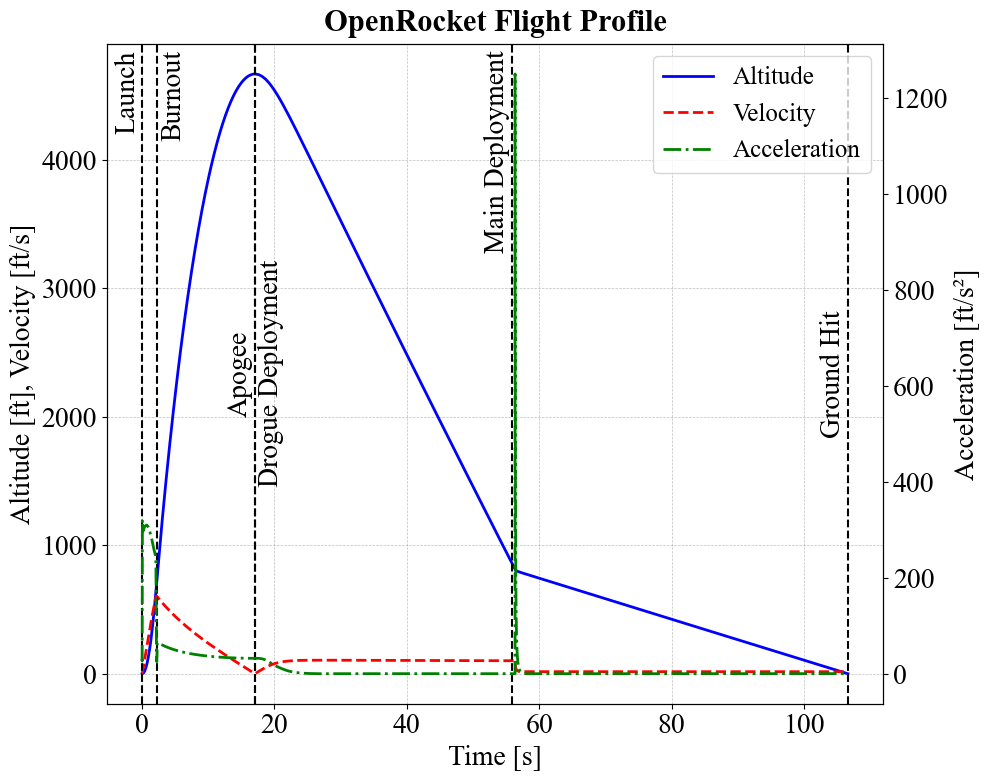

In [8]:
fig, ax1, ax2 = openrocket_to_plot('OpenRocket Full Scale Flight.csv', plot_type='all')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

ax1.legend(h1 + h2, l1 + l2, loc='upper right')
fig.suptitle('OpenRocket Flight Profile', y=0.97)

# fig.savefig('OpenRocket Full Scale Flight Profile.png', dpi=300)

plt.show()

Plotting custom simulation flight profile

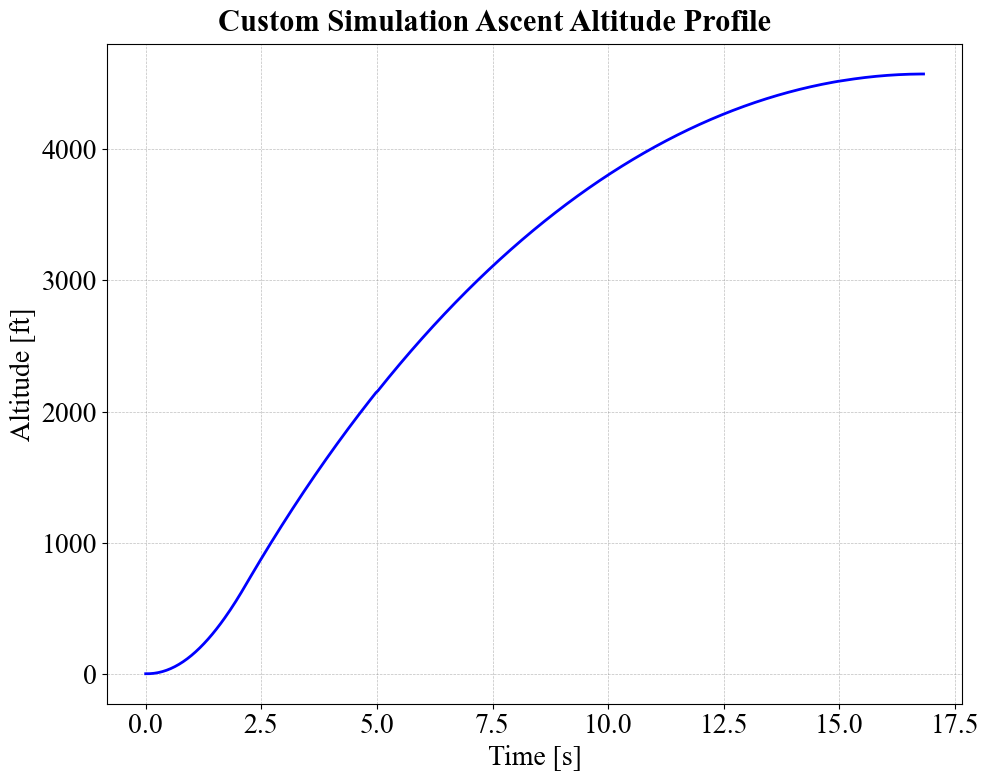

In [9]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

ax.plot(data_custom2['Time [s]'], data_custom2['Altitude [ft]'], linestyle='-', color='b', label='Custom', linewidth=2)

fig.suptitle('Custom Simulation Ascent Altitude Profile', y=0.97)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Altitude [ft]')
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# fig.savefig('Custom Simulation Ascent Altitude Profile.png', dpi=300)

plt.show()

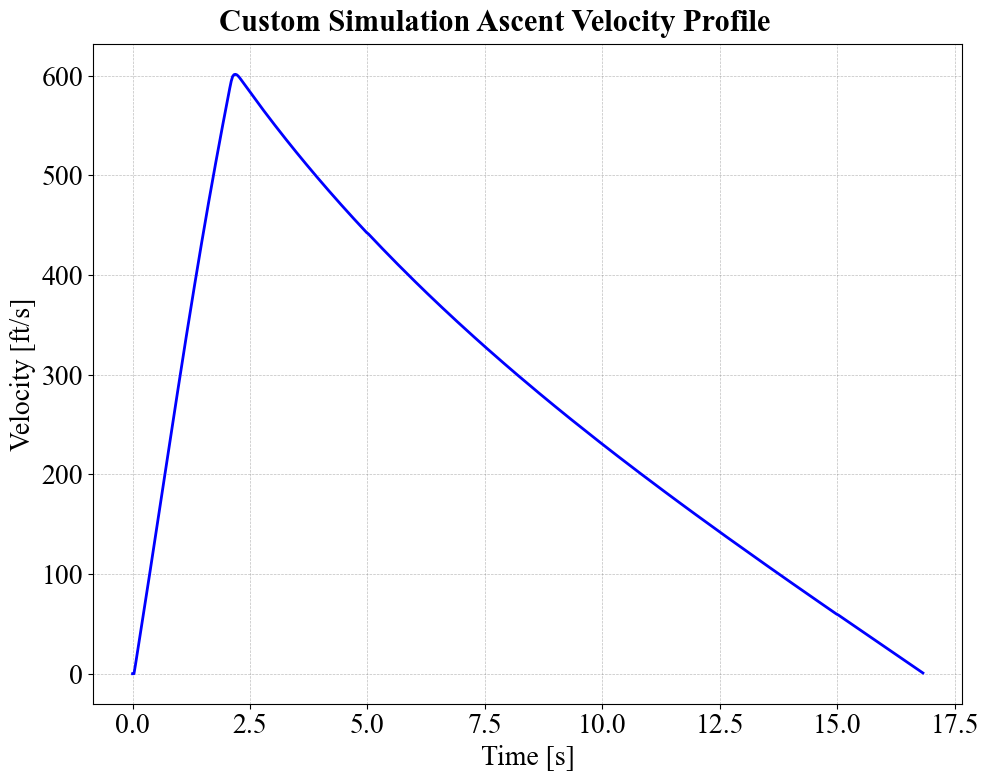

In [10]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

ax.plot(data_custom2['Time [s]'], data_custom2['Velocity [ft/s]'], linestyle='-', color='b', label='Custom', linewidth=2)

fig.suptitle('Custom Simulation Ascent Velocity Profile', y=0.97)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Velocity [ft/s]')
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# fig.savefig('Custom Solver Full Scale Flight Profile.png', dpi=300)

plt.show()

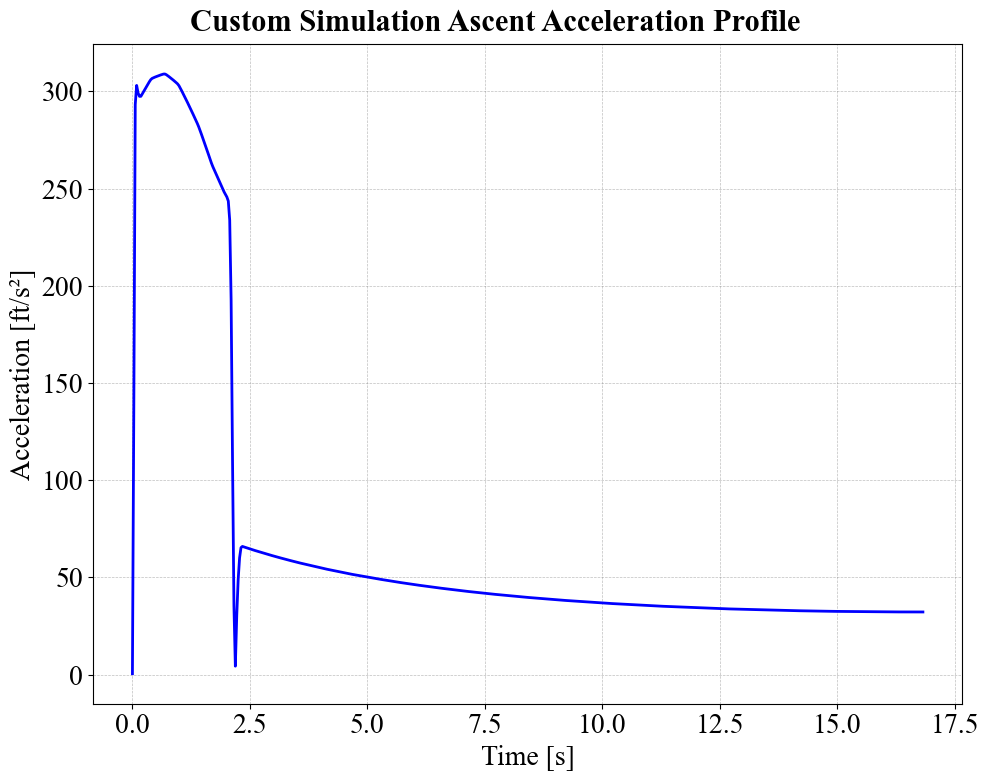

In [11]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

ax.plot(data_custom2['Time [s]'], data_custom2['Acceleration [ft/s²]'], linestyle='-', color='b', label='Custom', linewidth=2)

fig.suptitle('Custom Simulation Ascent Acceleration Profile', y=0.97)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Acceleration [ft/s²]')
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# fig.savefig('Custom Solver Full Scale Flight Profile.png', dpi=300)

plt.show()

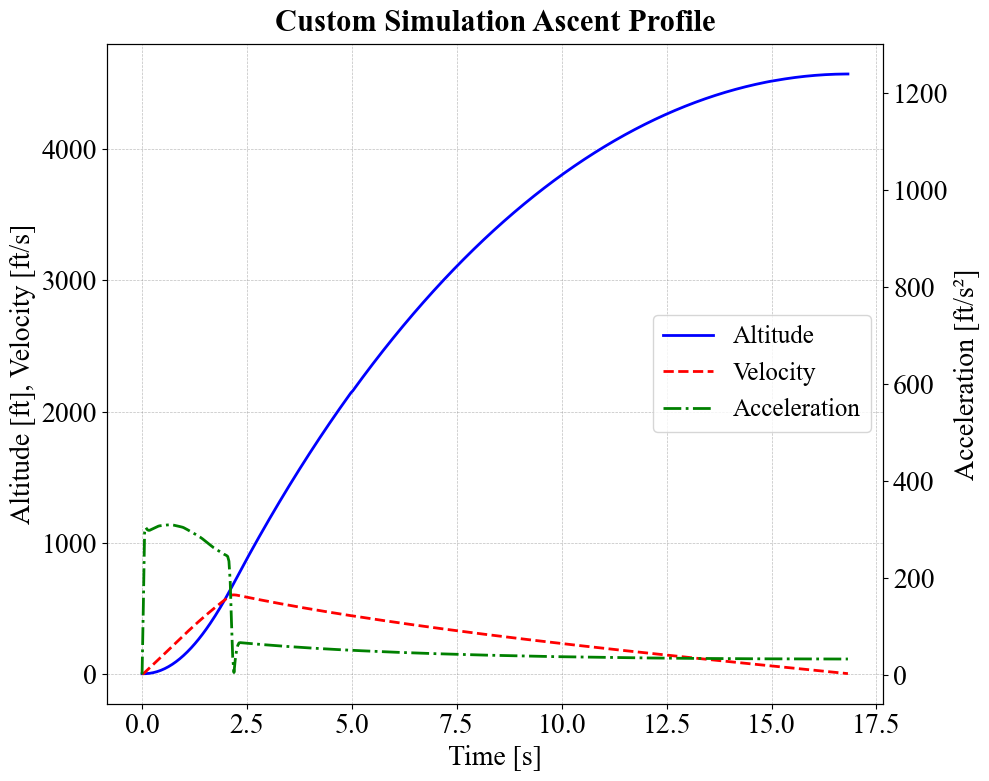

In [12]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

ax.plot(data_custom2['Time [s]'], data_custom2['Altitude [ft]'], linestyle='-', color='b', label='Altitude', linewidth=2)
ax.plot(data_custom2['Time [s]'], np.abs(data_custom2['Velocity [ft/s]']), linestyle='--', color='r', label='Velocity', linewidth=2)

ax2 = ax.twinx()
ax2.plot(data_custom2['Time [s]'], np.abs(data_custom2['Acceleration [ft/s²]']), linestyle='-.', color='g', label='Acceleration', linewidth=2)

ax2.set_ylim(-60, 1300)

fig.suptitle('Custom Simulation Ascent Profile', y=0.97)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Altitude [ft], Velocity [ft/s]')
ax2.set_ylabel('Acceleration [ft/s²]')

ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='center right')

# fig.savefig('Custom Simulation Ascent Profile.png', dpi=300)

plt.show()

Plotting avionics flight profile

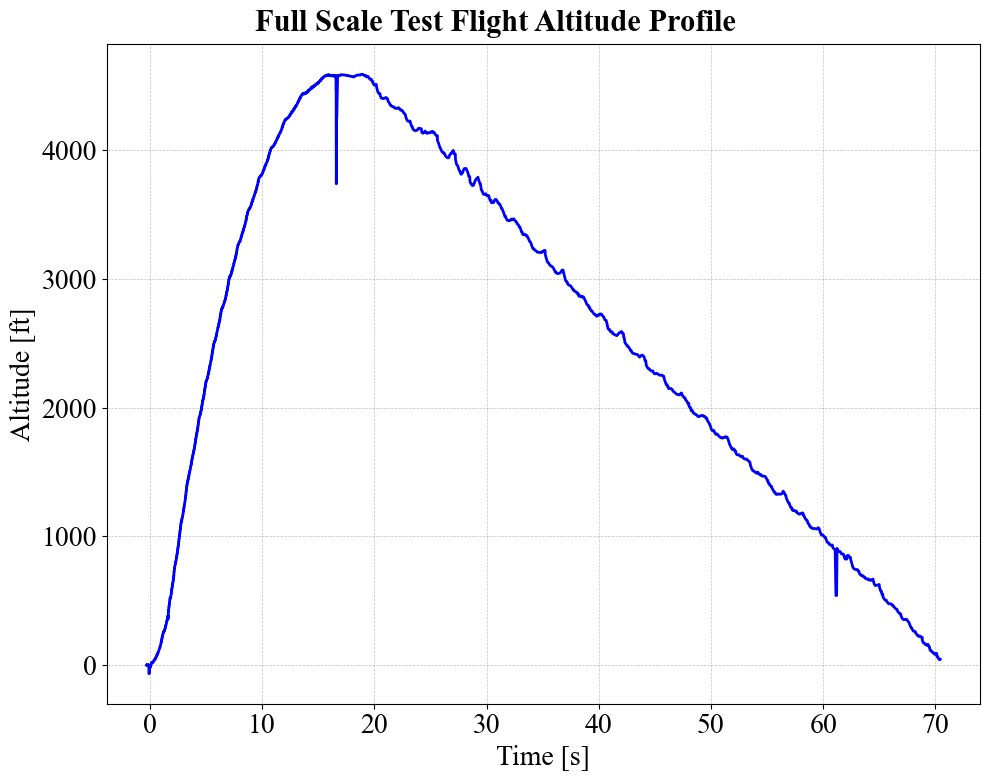

In [13]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

ax.plot(data_avionics2['Time [s]'], data_avionics2['Altitude [ft]'], linestyle='-', color='b', label='Avionics', linewidth=2)

fig.suptitle('Full Scale Test Flight Altitude Profile', y=0.97)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Altitude [ft]')
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# fig.savefig('Full Scale Test Flight Altitude Profile.png', dpi=300)

plt.show()

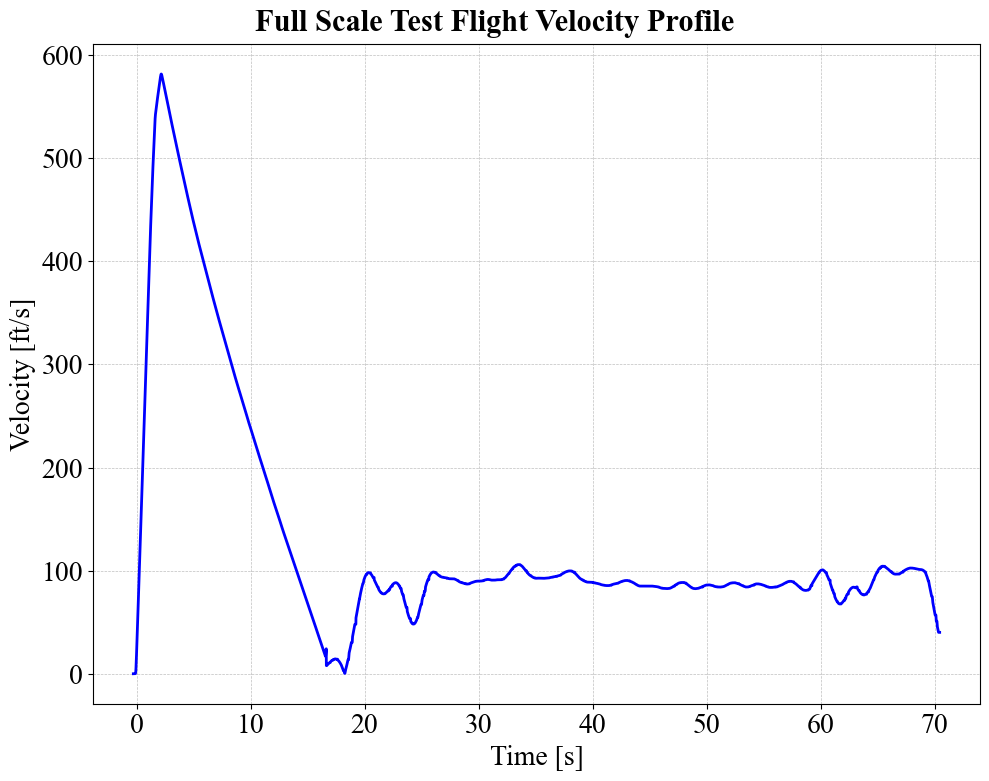

In [14]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

ax.plot(data_avionics2['Time [s]'], data_avionics2['Velocity [ft/s]'], linestyle='-', color='b', label='Avionics', linewidth=2)

fig.suptitle('Full Scale Test Flight Velocity Profile', y=0.97)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Velocity [ft/s]')
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# fig.savefig('Full Scale Test Flight Profile.png', dpi=300)

plt.show()

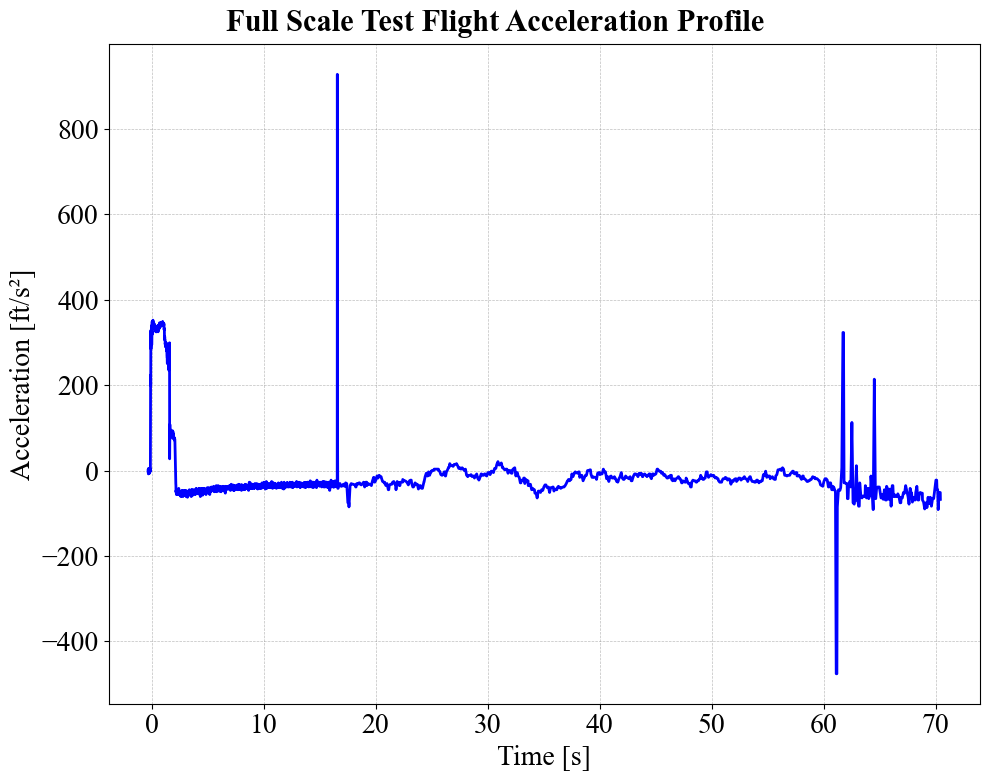

In [15]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

ax.plot(data_avionics2['Time [s]'], data_avionics2['Acceleration [ft/s²]'], linestyle='-', color='b', label='Avionics', linewidth=2)

fig.suptitle('Full Scale Test Flight Acceleration Profile', y=0.97)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Acceleration [ft/s²]')
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# fig.savefig('Full Scale Test Flight Profile.png', dpi=300)

plt.show()

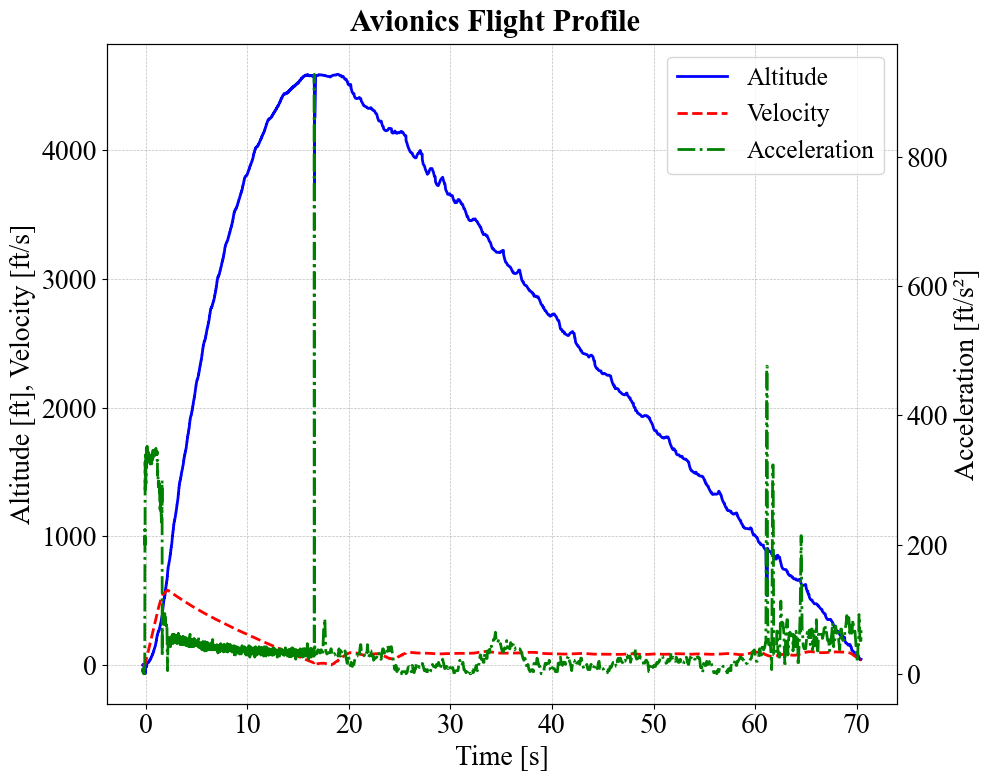

In [16]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

ax.plot(data_avionics2['Time [s]'], data_avionics2['Altitude [ft]'], linestyle='-', color='b', label='Altitude', linewidth=2)
ax.plot(data_avionics2['Time [s]'], np.abs(data_avionics2['Velocity [ft/s]']), linestyle='--', color='r', label='Velocity', linewidth=2)

ax2 = ax.twinx()
ax2.plot(data_avionics2['Time [s]'], np.abs(data_avionics2['Acceleration [ft/s²]']), linestyle='-.', color='g', label='Acceleration', linewidth=2)

fig.suptitle('Avionics Flight Profile', y=0.97)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Altitude [ft], Velocity [ft/s]')
ax2.set_ylabel('Acceleration [ft/s²]')

ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='upper right')

fig.savefig('Avionics Flight Profile.png', dpi=300)

plt.show()

## Comparison plots

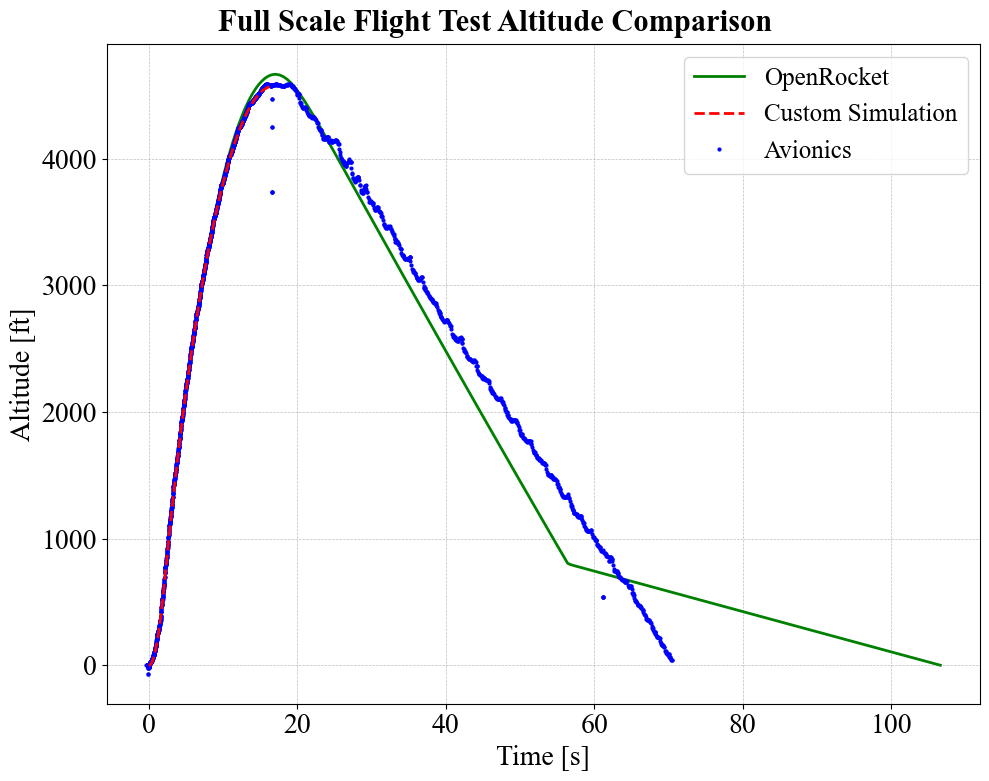

In [17]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

# Plotting the comparison plots between OpenRocket, custom simulation, and avionics
ax.plot(data_openrocket2['Time [s]'], data_openrocket2['Altitude [ft]'], linestyle='-', color='g', label='OpenRocket', linewidth=2)
ax.plot(data_custom2['Time [s]'], data_custom2['Altitude [ft]'], linestyle='--', color='r', label='Custom Simulation', linewidth=2, zorder=5)
ax.plot(data_avionics2['Time [s]'], data_avionics2['Altitude [ft]'], linestyle='None', marker='o', color='b', label='Avionics', markersize=2)

fig.suptitle('Full Scale Flight Test Altitude Comparison', y=0.97)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Altitude [ft]')
ax.legend(loc='upper right')
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# fig.savefig('Full Scale Flight Comparison.png', dpi=300)
plt.show()

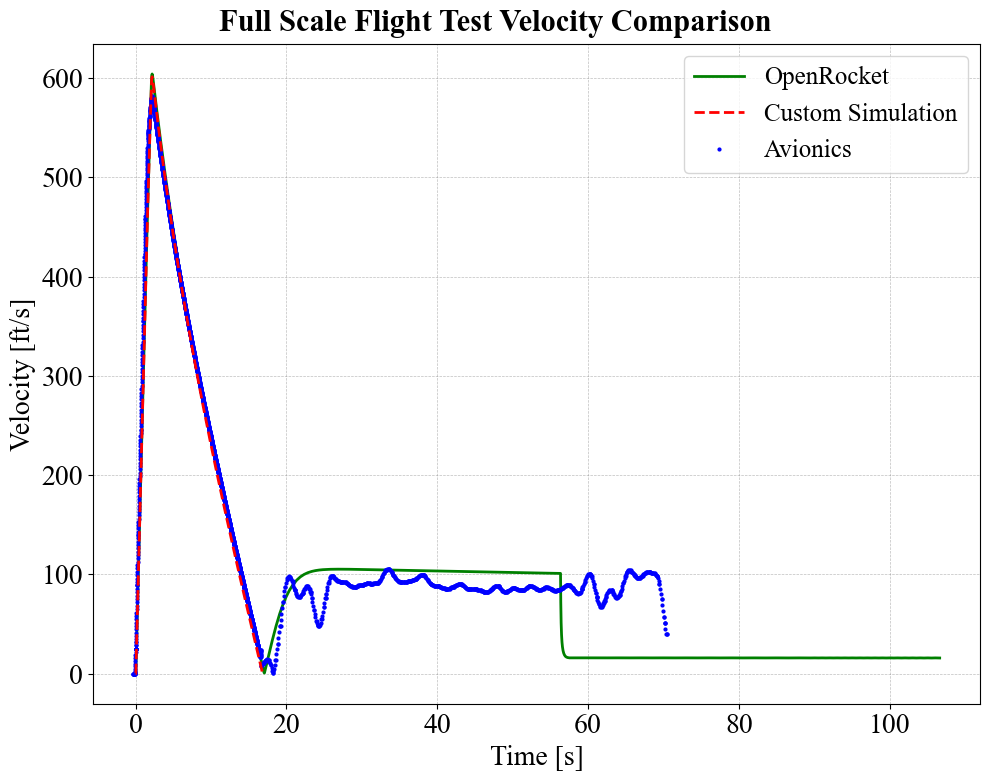

In [18]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

# Plotting the velocity comparison plots between OpenRocket, custom simulation, and avionics
ax.plot(data_openrocket2['Time [s]'], data_openrocket2['Velocity [ft/s]'], linestyle='-', color='g', label='OpenRocket', linewidth=2)
ax.plot(data_custom2['Time [s]'], data_custom2['Velocity [ft/s]'], linestyle='--', color='r', label='Custom Simulation', linewidth=2, zorder=5)
ax.plot(data_avionics2['Time [s]'], data_avionics2['Velocity [ft/s]'], linestyle='None', marker='o', color='b', label='Avionics', markersize=2)

fig.suptitle('Full Scale Flight Test Velocity Comparison', y=0.97)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Velocity [ft/s]')
ax.legend(loc='upper right')
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# fig.savefig('Full Scale Flight Comparison.png', dpi=300)
plt.show()

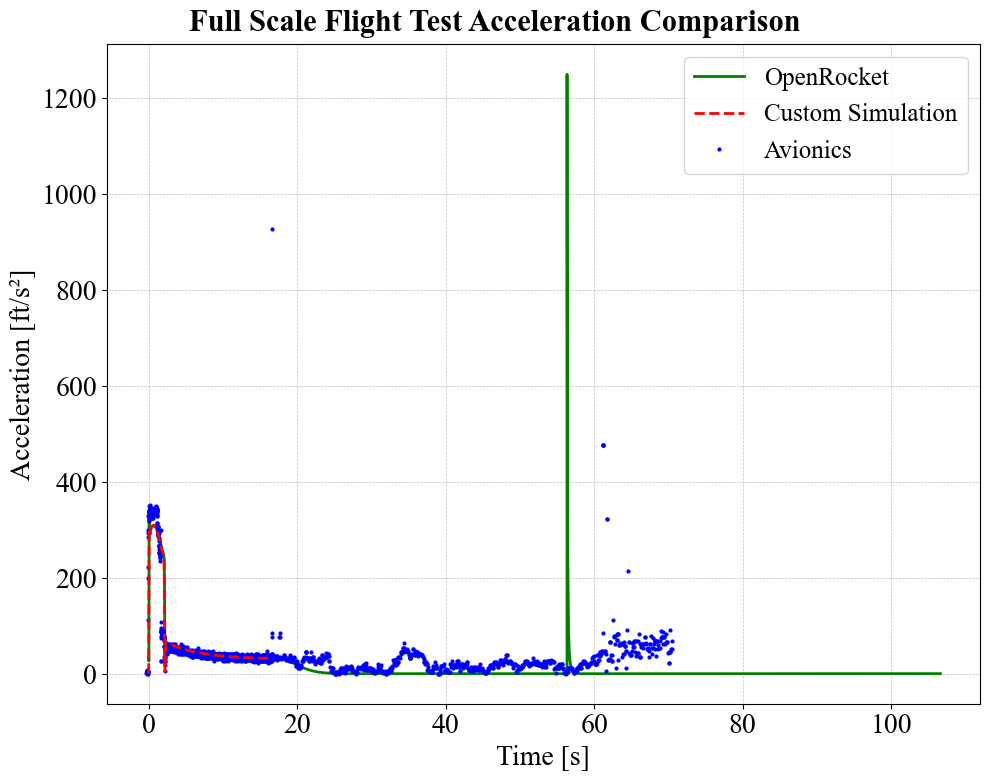

In [19]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

# Plotting the acceleration comparison plots between OpenRocket, custom simulation, and avionics
ax.plot(data_openrocket2['Time [s]'], data_openrocket2['Acceleration [ft/s²]'], linestyle='-', color='g', label='OpenRocket', linewidth=2)
ax.plot(data_custom2['Time [s]'], data_custom2['Acceleration [ft/s²]'], linestyle='--', color='r', label='Custom Simulation', linewidth=2, zorder=5)
ax.plot(data_avionics2['Time [s]'], np.abs(data_avionics2['Acceleration [ft/s²]']), linestyle='None', marker='o', color='b', label='Avionics', markersize=2)

fig.suptitle('Full Scale Flight Test Acceleration Comparison', y=0.97)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Acceleration [ft/s²]')
ax.legend(loc='upper right')
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# fig.savefig('Full Scale Flight Comparison.png', dpi=300)
plt.show()

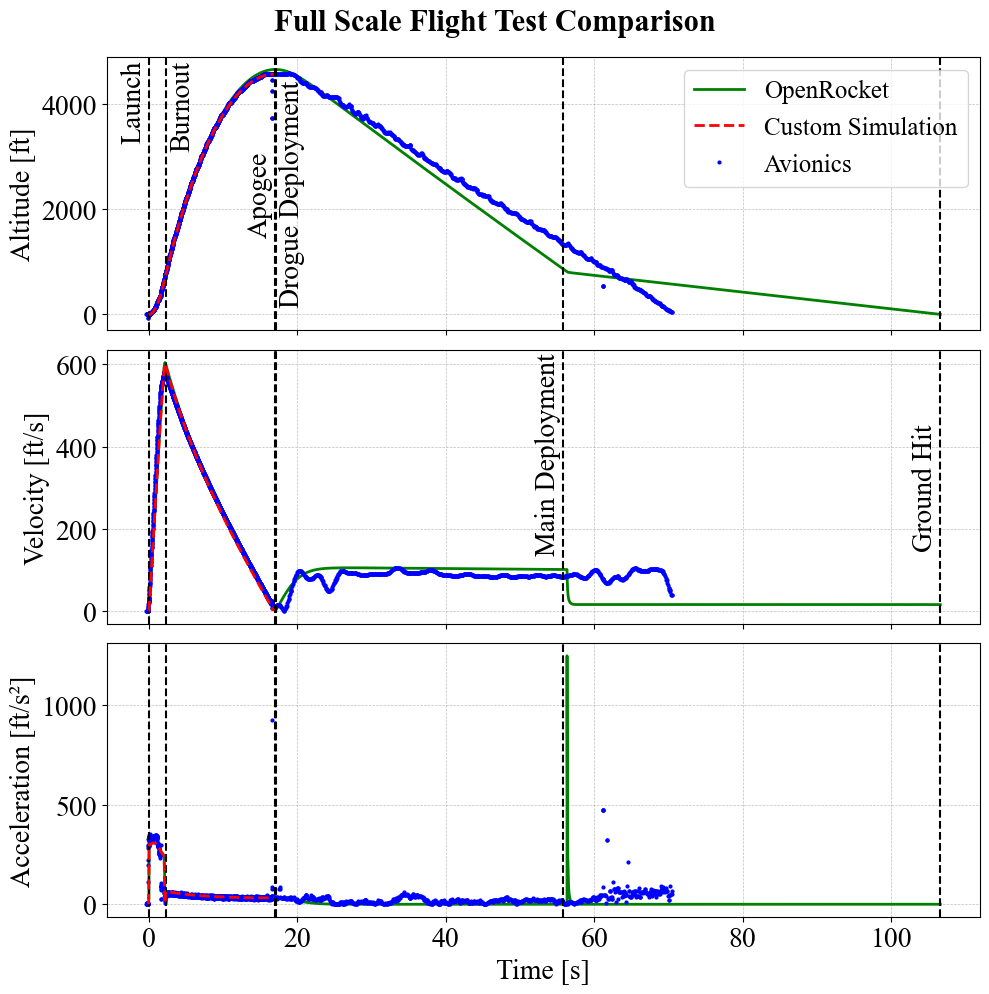

In [66]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
fig.set_tight_layout(True)

# Altitude comparison
ax1.plot(data_openrocket2['Time [s]'], data_openrocket2['Altitude [ft]'], linestyle='-', color='g', label='OpenRocket', linewidth=2)
ax1.plot(data_custom2['Time [s]'], data_custom2['Altitude [ft]'], linestyle='--', color='r', label='Custom Simulation', linewidth=2, zorder=5)
ax1.plot(data_avionics2['Time [s]'], data_avionics2['Altitude [ft]'], linestyle='None', marker='o', color='b', label='Avionics', markersize=2)
ax1.set_ylabel('Altitude [ft]')
ax1.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Velocity comparison
ax2.plot(data_openrocket2['Time [s]'], data_openrocket2['Velocity [ft/s]'], linestyle='-', color='g', linewidth=2)
ax2.plot(data_custom2['Time [s]'], data_custom2['Velocity [ft/s]'], linestyle='--', color='r', linewidth=2, zorder=5)
ax2.plot(data_avionics2['Time [s]'], data_avionics2['Velocity [ft/s]'], linestyle='None', marker='o', color='b', markersize=2)
ax2.set_ylabel('Velocity [ft/s]')
ax2.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Acceleration comparison
ax3.plot(data_openrocket2['Time [s]'], data_openrocket2['Acceleration [ft/s²]'], linestyle='-', color='g', linewidth=2)
ax3.plot(data_custom2['Time [s]'], data_custom2['Acceleration [ft/s²]'], linestyle='--', color='r', linewidth=2, zorder=5)
ax3.plot(data_avionics2['Time [s]'], np.abs(data_avionics2['Acceleration [ft/s²]']), linestyle='None', marker='o', color='b', markersize=2)
ax3.set_ylabel('Acceleration [ft/s²]')
ax3.set_xlabel('Time [s]')
ax3.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Single legend for all three subplots (from first subplot's labels)
ax1.legend(loc='upper right')

# Adding vertical lines for important flight events, from OpenRocket file
with open('OpenRocket Full Scale Flight.csv', 'r') as f:
    lines = f.readlines()
    event_lines = [line for line in lines if line.startswith('#') and 'Event' in line]

events = [line.split('Event ')[1].split(' occurred at t=')[0] for line in event_lines]
event_times = [float(line.split('t=')[1].split(' seconds')[0]) for line in event_lines]

plot_events = ['LAUNCH', 'BURNOUT', 'APOGEE', 'RECOVERY_DEVICE_DEPLOYMENT', 'GROUND_HIT']

drogue_deployed = False
for event, event_time in zip(events, event_times):
    if event in plot_events:
        for ax in [ax1, ax2, ax3]:
            ax.axvline(event_time, linestyle='--', color='k')

        if event == 'RECOVERY_DEVICE_DEPLOYMENT':
            if not drogue_deployed:
                event_label = 'Drogue Deployment'
                drogue_deployed = True
                ax1.text(event_time + 0.5, np.mean(ax1.get_ylim()), event_label, rotation=90, verticalalignment='center', horizontalalignment='left', fontsize=20)
            else:
                event_label = 'Main Deployment'
                ax2.text(event_time - 0.3, 0.99 * ax2.get_ylim()[1], event_label, rotation=90, verticalalignment='top', horizontalalignment='right', fontsize=20)
        elif event == 'BURNOUT':
            ax1.text(event_time + 0.5, 0.99 * ax1.get_ylim()[1], event.replace('_', ' ').title(), rotation=90, verticalalignment='top', horizontalalignment='left', fontsize=20)
        elif event == 'APOGEE':
            ax1.text(event_time - 0.3, np.mean(ax1.get_ylim()), event.replace('_', ' ').title(), rotation=90, verticalalignment='center', horizontalalignment='right', fontsize=20)
        elif event == 'GROUND_HIT':
            ax2.text(event_time - 0.3, np.mean(ax2.get_ylim()), event.replace('_', ' ').title(), rotation=90, verticalalignment='center', horizontalalignment='right', fontsize=20)
        else:
            ax1.text(event_time - 0.3, 0.99 * ax1.get_ylim()[1], event.replace('_', ' ').title(), rotation=90, verticalalignment='top', horizontalalignment='right', fontsize=20)

fig.suptitle('Full Scale Flight Test Comparison', y=0.99)

fig.savefig('Full Scale Flight Test Comparison.png', dpi=300)
plt.show()

## Analyzing descent

In [21]:
# Drogue parachute fit
drogue_descent_velocities_avionics = data_avionics2['Velocity [ft/s]'][(data_avionics2['Time [s]'] > 25) & (data_avionics2['Time [s]'] < 55)]
drogue_descent_velocities_openrocket = data_openrocket2['Velocity [ft/s]'][(data_openrocket2['Time [s]'] > 25) & (data_openrocket2['Time [s]'] < 55)]
print(f'Drogue Descent Rate, Average (Avionics): {np.mean(drogue_descent_velocities_avionics):.2f} ft/s')
print(f'Drogue Descent Rate, Average (OpenRocket): {np.mean(drogue_descent_velocities_openrocket):.2f} ft/s')
print(f'Percent error between OpenRocket and Avionics: {100 * abs(np.mean(drogue_descent_velocities_openrocket) - np.mean(drogue_descent_velocities_avionics)) / np.mean(drogue_descent_velocities_avionics):.2f}%')

# Main parachute fit
main_descent_velocities_avionics = data_avionics2['Velocity [ft/s]'][(data_avionics2['Time [s]'] > 62) & (data_avionics2['Time [s]'] < 70)]
main_descent_velocities_openrocket = data_openrocket2['Velocity [ft/s]'][(data_openrocket2['Time [s]'] > 60) & (data_openrocket2['Time [s]'] < 80)]
print(f'Main Descent Rate, Average (Avionics): {np.mean(main_descent_velocities_avionics):.2f} ft/s')
print(f'Main Descent Rate, Average (OpenRocket): {np.mean(main_descent_velocities_openrocket):.2f} ft/s')
print(f'Percent error between OpenRocket and Avionics: {100 * abs(np.mean(main_descent_velocities_openrocket) - np.mean(main_descent_velocities_avionics)) / np.mean(main_descent_velocities_avionics):.2f}%')

Drogue Descent Rate, Average (Avionics): 89.65 ft/s
Drogue Descent Rate, Average (OpenRocket): 103.46 ft/s
Percent error between OpenRocket and Avionics: 15.41%
Main Descent Rate, Average (Avionics): 91.77 ft/s
Main Descent Rate, Average (OpenRocket): 15.97 ft/s
Percent error between OpenRocket and Avionics: 82.59%


In [22]:
drogue_data_avionics = data_avionics2[(data_avionics2['Time [s]'].values > 25) & (data_avionics2['Time [s]'].values < 55)]
drogue_data_openrocket = data_openrocket2[(data_openrocket2['Time [s]'].values > 25) & (data_openrocket2['Time [s]'].values < 55)]

main_data_avionics = data_avionics2[(data_avionics2['Time [s]'].values > 62) & (data_avionics2['Time [s]'].values < 70)]
main_data_openrocket = data_openrocket2[(data_openrocket2['Time [s]'].values > 60) & (data_openrocket2['Time [s]'].values < 80)]

# Drogue parachute fit
drogue_fit_avionics = np.polyfit(drogue_data_avionics['Time [s]'], drogue_data_avionics['Altitude [ft]'], 1)
drogue_fit_openrocket = np.polyfit(drogue_data_openrocket['Time [s]'], drogue_data_openrocket['Altitude [ft]'], 1)

# Main parachute fit
main_fit_avionics = np.polyfit(main_data_avionics['Time [s]'], main_data_avionics['Altitude [ft]'], 1)
main_fit_openrocket = np.polyfit(main_data_openrocket['Time [s]'], main_data_openrocket['Altitude [ft]'], 1)

print(f'Drogue Descent Rate, Slope (Avionics): {drogue_fit_avionics[0]:.2f} ft/s')
print(f'Drogue Descent Rate, Slope (OpenRocket): {drogue_fit_openrocket[0]:.2f} ft/s')

print(f'Main Descent Rate, Slope (Avionics): {main_fit_avionics[0]:.2f} ft/s')
print(f'Main Descent Rate, Slope (OpenRocket): {main_fit_openrocket[0]:.2f} ft/s')

Drogue Descent Rate, Slope (Avionics): -90.34 ft/s
Drogue Descent Rate, Slope (OpenRocket): -103.48 ft/s
Main Descent Rate, Slope (Avionics): -96.12 ft/s
Main Descent Rate, Slope (OpenRocket): -15.97 ft/s


Showing the velocity fits

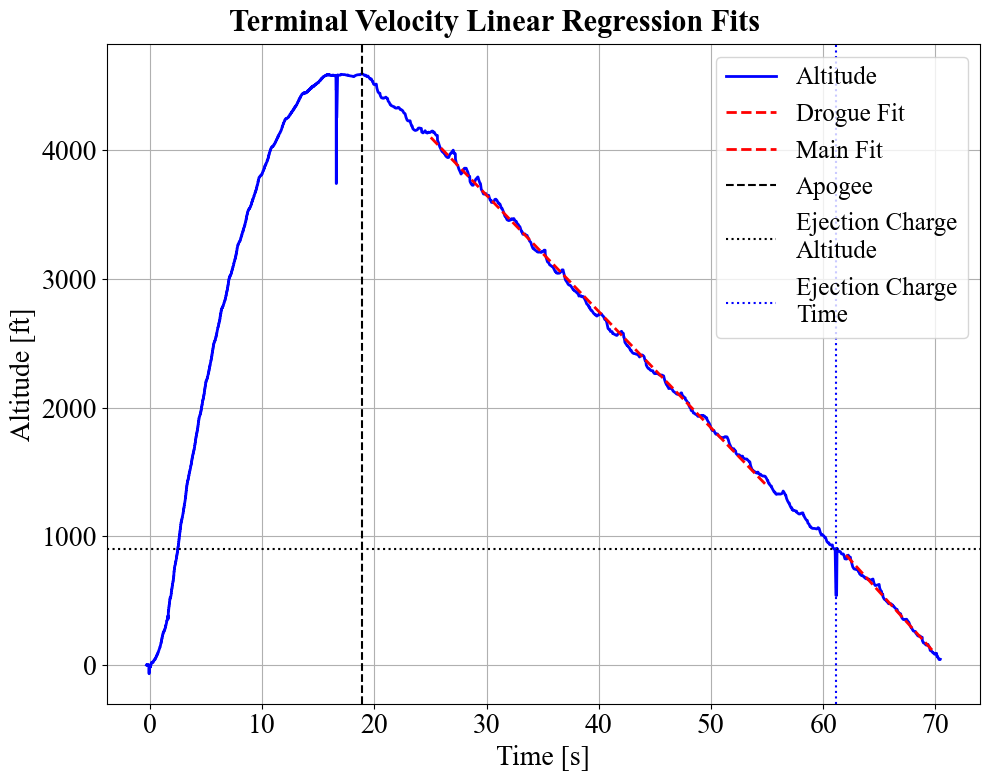

In [23]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

ax.plot(data_avionics2['Time [s]'], data_avionics2['Altitude [ft]'], linestyle='-', color='b', label='Altitude', linewidth=2)
ax.plot(drogue_data_avionics['Time [s]'], np.polyval(drogue_fit_avionics, drogue_data_avionics['Time [s]']), linestyle='--', color='r', linewidth=2, label='Drogue Fit')
ax.plot(main_data_avionics['Time [s]'], np.polyval(main_fit_avionics, main_data_avionics['Time [s]']), linestyle='--', color='r', linewidth=2, label='Main Fit')

ax.axvline(time_to_apogee_avionics, color='k', linestyle='dashed', label='Apogee')
ax.axhline(900, color='k', linestyle=':', label='Ejection Charge\nAltitude')

ax.axvline(61.1, color='b', linestyle=':', label='Ejection Charge\nTime')

fig.suptitle('Terminal Velocity Linear Regression Fits', y=0.97)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Altitude [ft]')
ax.grid(True)

ax.legend(loc='upper right', ncol=1)

# fig.savefig('Avionics Terminal Velocity Fits.png', dpi=300)

plt.show()

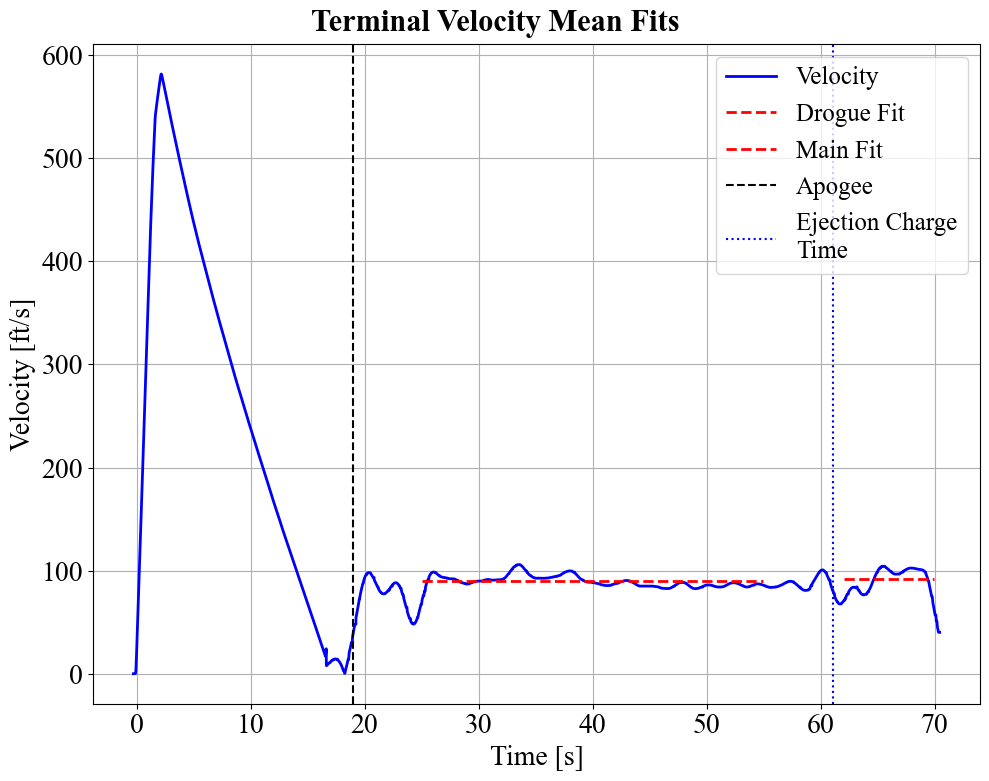

In [24]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

ax.plot(data_avionics2['Time [s]'], data_avionics2['Velocity [ft/s]'], linestyle='-', color='b', label='Velocity', linewidth=2)

ax.hlines(np.mean(drogue_data_avionics["Velocity [ft/s]"]), drogue_data_avionics['Time [s]'].min(), drogue_data_avionics['Time [s]'].max(), linestyle='--', color='r', linewidth=2, label='Drogue Fit')

ax.hlines(np.mean(main_data_avionics["Velocity [ft/s]"]), main_data_avionics['Time [s]'].min(), main_data_avionics['Time [s]'].max(), linestyle='--', color='r', linewidth=2, label='Main Fit')

ax.axvline(time_to_apogee_avionics, color='k', linestyle='dashed', label='Apogee')

ax.axvline(61.1, color='b', linestyle=':', label='Ejection Charge\nTime')

fig.suptitle('Terminal Velocity Mean Fits', y=0.97)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Velocity [ft/s]')
ax.grid(True)

ax.legend(loc='upper right', ncol=1)

# fig.savefig('Avionics Terminal Velocity Fits.png', dpi=300)

plt.show()

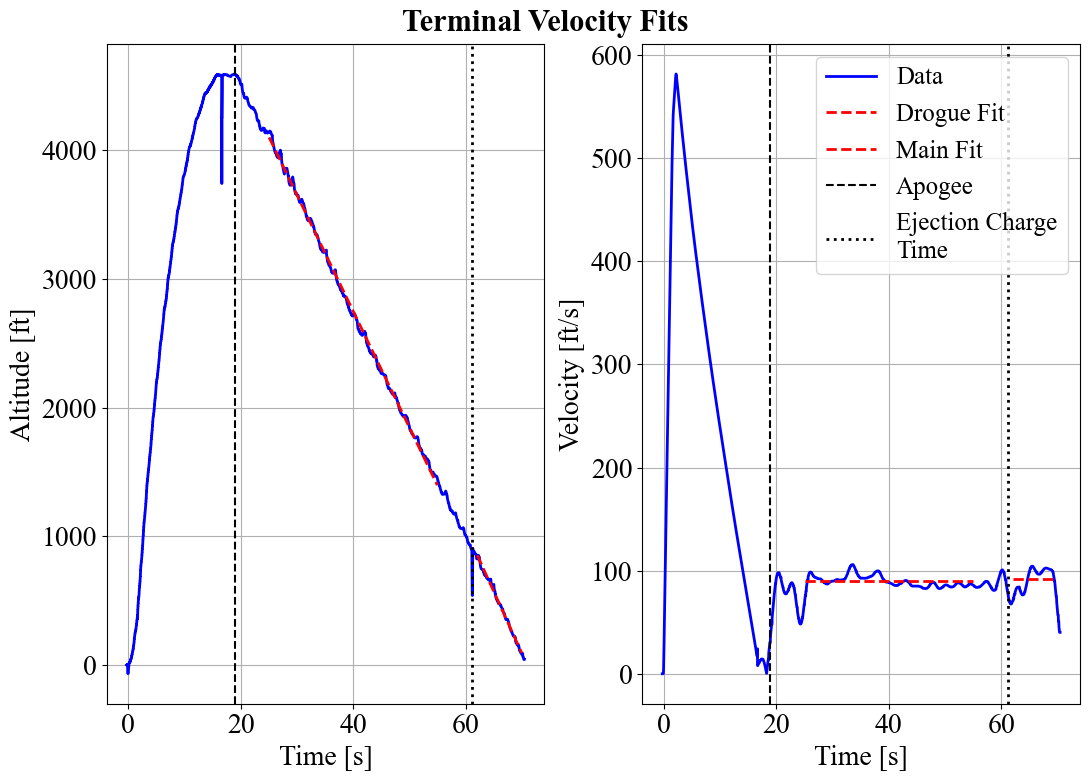

In [25]:
fig = plt.figure(figsize=(11, 8))
fig.set_tight_layout(True)
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

ax1.plot(data_avionics2['Time [s]'], data_avionics2['Altitude [ft]'], linestyle='-', color='b', label='Altitude', linewidth=2)

ax1.plot(drogue_data_avionics['Time [s]'], np.polyval(drogue_fit_avionics, drogue_data_avionics['Time [s]']), linestyle='--', color='r', linewidth=2, label='Drogue Fit')

ax1.plot(main_data_avionics['Time [s]'], np.polyval(main_fit_avionics, main_data_avionics['Time [s]']), linestyle='--', color='r', linewidth=2, label='Main Fit')

ax1.axvline(time_to_apogee_avionics, color='k', linestyle='dashed', label='Apogee')
# ax1.axhline(700, color='k', linestyle=':', label='Ejection Charge\nAltitude')

ax1.axvline(61.1, color='k', linestyle=':', label='Ejection Charge\nTime', linewidth=2)

fig.suptitle('Terminal Velocity Linear Regression Fits', y=0.97)
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Altitude [ft]')
ax1.grid(True)

# ax1.legend(loc='upper right', ncol=1)

ax2.plot(data_avionics2['Time [s]'], data_avionics2['Velocity [ft/s]'], linestyle='-', color='b', label='Data', linewidth=2)

ax2.hlines(np.mean(drogue_data_avionics["Velocity [ft/s]"]), drogue_data_avionics['Time [s]'].min(), drogue_data_avionics['Time [s]'].max(), linestyle='--', color='r', linewidth=2, label='Drogue Fit')

ax2.hlines(np.mean(main_data_avionics["Velocity [ft/s]"]), main_data_avionics['Time [s]'].min(), main_data_avionics['Time [s]'].max(), linestyle='--', color='r', linewidth=2, label='Main Fit')
ax2.axvline(time_to_apogee_avionics, color='k', linestyle='dashed', label='Apogee')
# ax2.axhline(700, color='k', linestyle=':', label='Ejection Charge\nAltitude')

ax2.axvline(61.1, color='k', linestyle=':', label='Ejection Charge\nTime', linewidth=2)

fig.suptitle('Terminal Velocity Fits', y=0.97)
ax2.set_xlabel('Time [s]')
ax2.set_ylabel('Velocity [ft/s]')
ax2.grid(True)

ax2.legend(loc='upper right', ncol=1)

# fig.savefig('Avionics Terminal Velocity Fits Combined.png', dpi=300)

plt.show()

## Seeing various conditions

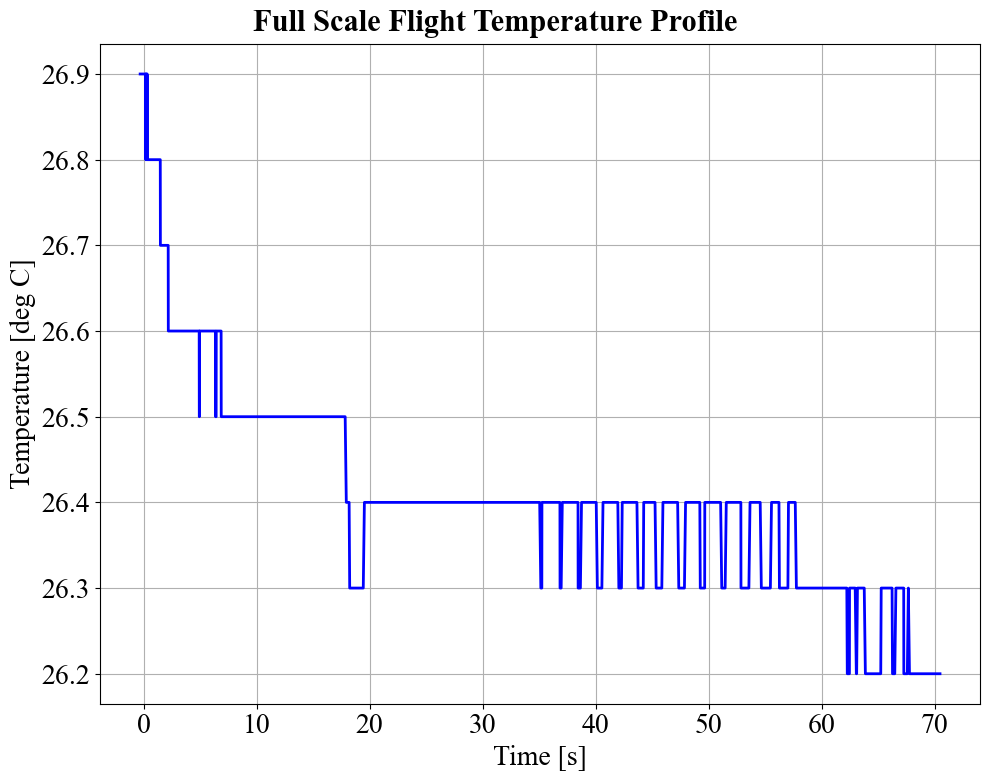

In [26]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

fig.suptitle('Full Scale Flight Temperature Profile', y=0.97)

ax.plot(data_avionics2['Time [s]'], data_avionics2['temperature'], linestyle='-', color='b', label='Avionics', linewidth=2)

ax.set_xlabel('Time [s]')
ax.set_ylabel('Temperature [deg C]')
ax.grid(True)

plt.show()

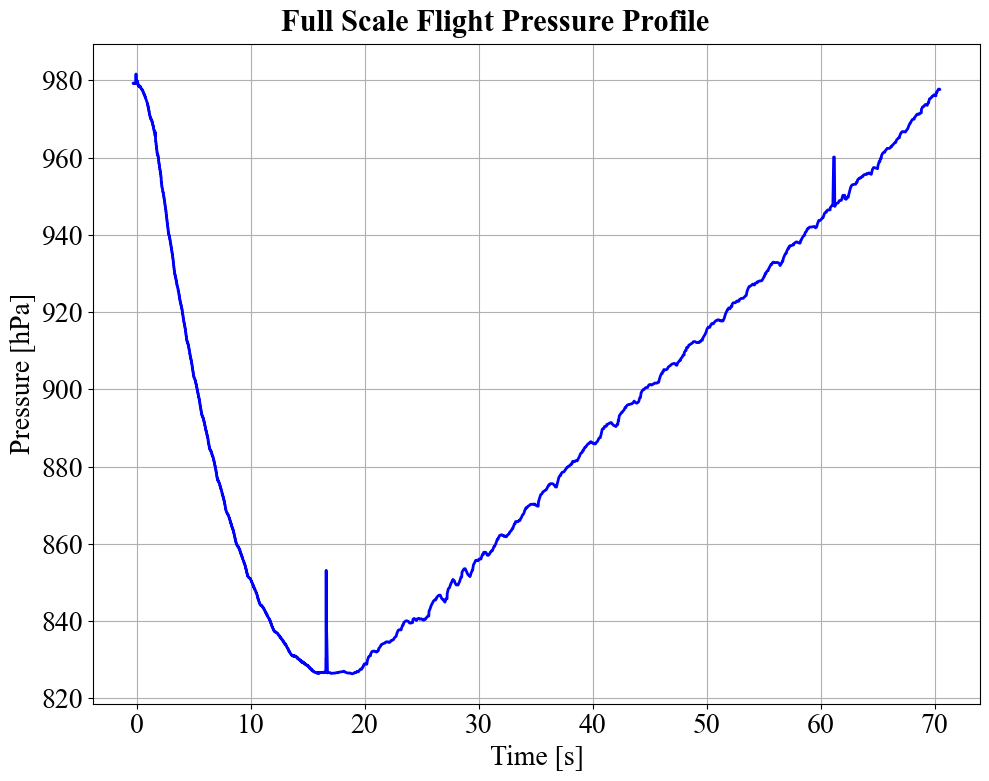

In [27]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

fig.suptitle('Full Scale Flight Pressure Profile', y=0.97)

ax.plot(data_avionics2['Time [s]'], data_avionics2['pressure'] / 100, linestyle='-', color='b', label='Avionics', linewidth=2)

ax.set_xlabel('Time [s]')
ax.set_ylabel('Pressure [hPa]')
ax.grid(True)

plt.show()

Comparing the actual and simulated flights through interpolation and plotting

In [70]:
common_times = np.linspace(0, max(data_avionics2['Time [s]'].max(), data_openrocket2['Time [s]'].max()), num=1000)

# Interpolating avionics data
interp_avionics = interpolate.interp1d(data_avionics2['Time [s]'], data_avionics2['Altitude [ft]'], kind='linear', fill_value=0, bounds_error=False)
interp_altitudes_avionics = interp_avionics(common_times)

# Interpolating OpenRocket data
interp_openrocket = interpolate.interp1d(data_openrocket2['Time [s]'], data_openrocket2['Altitude [ft]'], kind='linear', fill_value=0, bounds_error=False)
interp_altitudes_openrocket = interp_openrocket(common_times)

# Interpolating custom simulation data
interp_custom = interpolate.interp1d(data_custom2['Time [s]'], data_custom2['Altitude [ft]'], kind='linear', fill_value=0, bounds_error=False)
interp_altitudes_custom = interp_custom(common_times)

# Interpolating velocity data
interp_vel_avionics = interpolate.interp1d(data_avionics2['Time [s]'], data_avionics2['Velocity [ft/s]'], kind='linear', fill_value=0, bounds_error=False)(common_times)
interp_vel_openrocket = interpolate.interp1d(data_openrocket2['Time [s]'], data_openrocket2['Velocity [ft/s]'], kind='linear', fill_value=0, bounds_error=False)(common_times)
interp_vel_custom = interpolate.interp1d(data_custom2['Time [s]'], data_custom2['Velocity [ft/s]'], kind='linear', fill_value=0, bounds_error=False)(common_times)

# Interpolating acceleration data
interp_acc_avionics = interpolate.interp1d(data_avionics2['Time [s]'], data_avionics2['Acceleration [ft/s²]'], kind='linear', fill_value=0, bounds_error=False)(common_times)
interp_acc_openrocket = interpolate.interp1d(data_openrocket2['Time [s]'], data_openrocket2['Acceleration [ft/s²]'], kind='linear', fill_value=0, bounds_error=False)(common_times)
interp_acc_custom = interpolate.interp1d(data_custom2['Time [s]'], data_custom2['Acceleration [ft/s²]'], kind='linear', fill_value=0, bounds_error=False)(common_times)

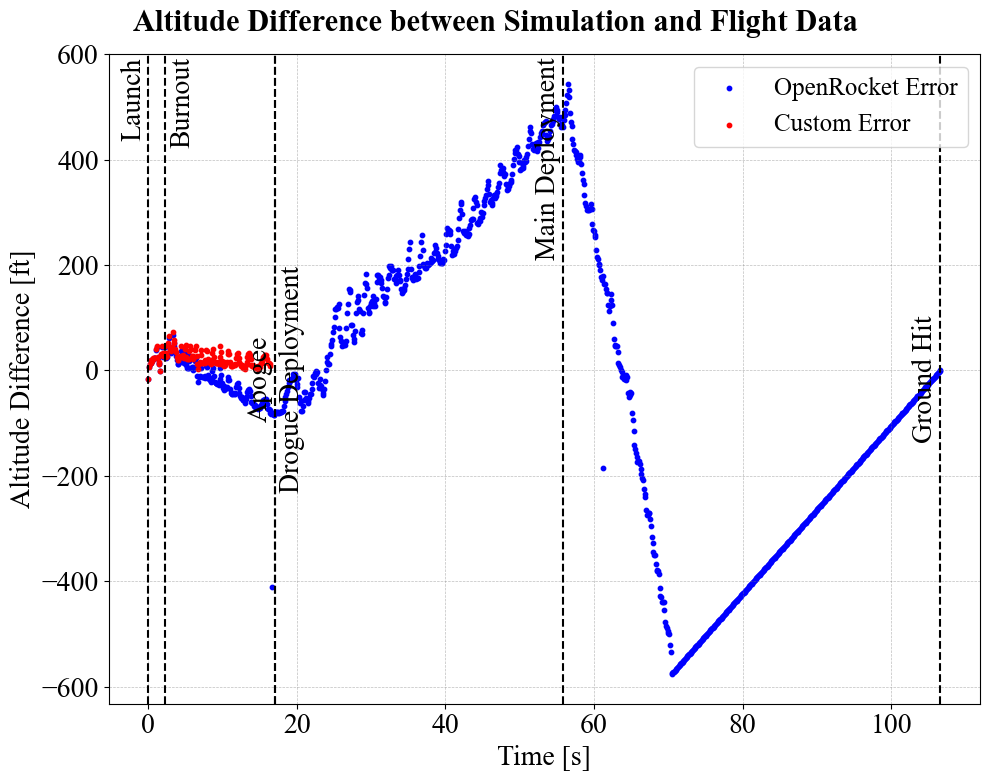

In [68]:
fig, ax = openrocket_to_plot('OpenRocket Full Scale Flight.csv', code_to_run="ax.scatter(common_times, interp_altitudes_avionics - interp_altitudes_openrocket, c='b', s=10, label='OpenRocket Error')")

ax.scatter(common_times[common_times <= 16.5], interp_altitudes_avionics[common_times <= 16.5] - interp_altitudes_custom[common_times <= 16.5], c='r', s=10, label='Custom Error')

# ax.plot(common_times, interp_altitudes_avionics - interp_altitudes_launch, linestyle='-', color='b', label='Avionics - Simulated', linewidth=2)

fig.suptitle('Altitude Difference between Simulation and Flight Data', y=0.97)
# fig.set_tight_layout(True)

# ax.set_xlim(-2, 32)

ax.set_xlabel('Time [s]')
ax.set_ylabel('Altitude Difference [ft]')

ax.legend(loc='upper right')

ax.grid(True)

# fig.savefig('Subscale_Altitude_Difference_Simulated_vs_Actual.png', dpi=300)

plt.show()

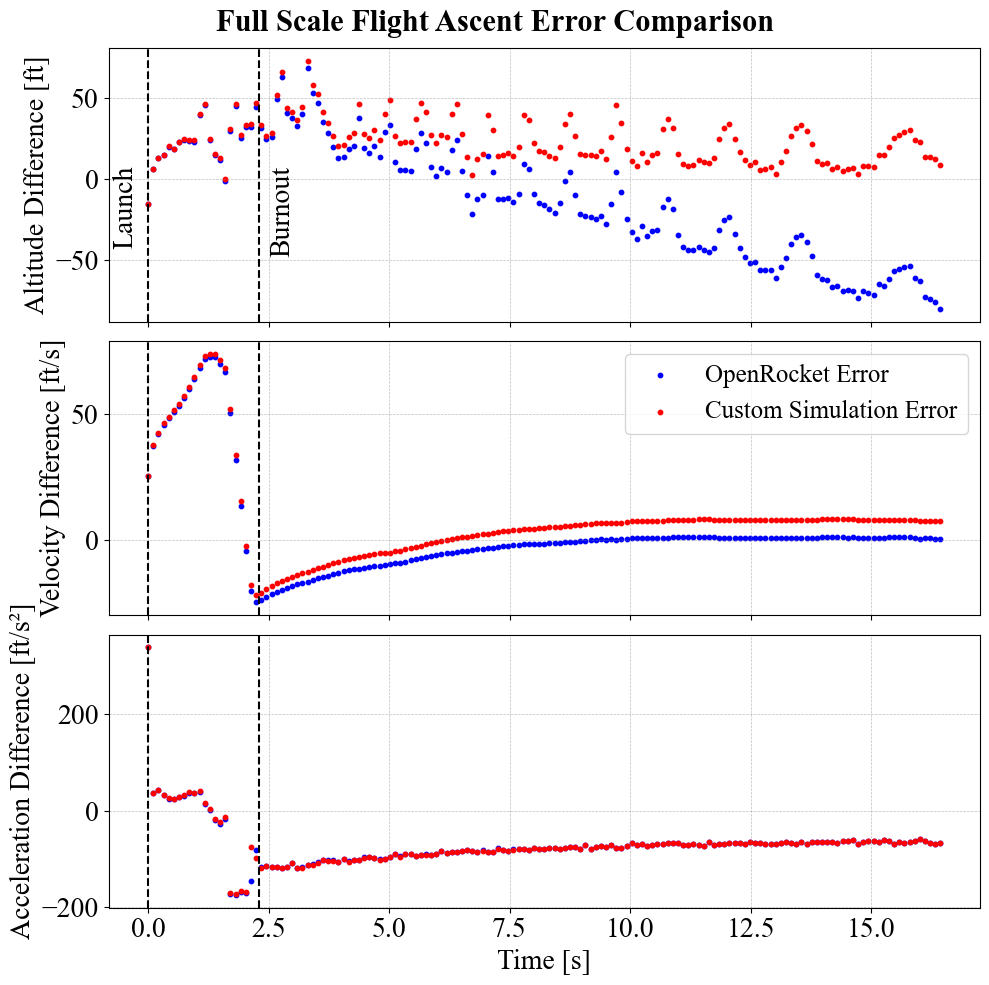

In [ ]:
t_mask = common_times <= 16.5
t_cut = common_times[t_mask]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
fig.set_tight_layout(True)

# Altitude difference
ax1.scatter(t_cut, (interp_altitudes_avionics - interp_altitudes_openrocket)[t_mask], c='b', s=10, label='OpenRocket Error')
ax1.scatter(t_cut, (interp_altitudes_avionics - interp_altitudes_custom)[t_mask], c='r', s=10, label='Custom Simulation Error')
ax1.set_ylabel('Altitude Difference [ft]')
ax1.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Velocity difference
ax2.scatter(t_cut, (interp_vel_avionics - interp_vel_openrocket)[t_mask], c='b', s=10, label='OpenRocket Error')
ax2.scatter(t_cut, (interp_vel_avionics - interp_vel_custom)[t_mask], c='r', s=10, label='Custom Simulation Error')
ax2.set_ylabel('Velocity Difference [ft/s]')
ax2.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Acceleration difference
ax3.scatter(t_cut, (interp_acc_avionics - interp_acc_openrocket)[t_mask], c='b', s=10, label='OpenRocket Error')
ax3.scatter(t_cut, (interp_acc_avionics - interp_acc_custom)[t_mask], c='r', s=10, label='Custom Simulation Error')
ax3.set_ylabel('Acceleration Difference [ft/s²]')
ax3.set_xlabel('Time [s]')
ax3.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

ax2.legend(loc='upper right')

# Adding vertical lines for flight events (excluding main deployment and ground hit)
with open('OpenRocket Full Scale Flight.csv', 'r') as f:
    lines = f.readlines()
    event_lines = [line for line in lines if line.startswith('#') and 'Event' in line]

events = [line.split('Event ')[1].split(' occurred at t=')[0] for line in event_lines]
event_times = [float(line.split('t=')[1].split(' seconds')[0]) for line in event_lines]

plot_events = ['LAUNCH', 'BURNOUT', 'APOGEE', 'RECOVERY_DEVICE_DEPLOYMENT']

drogue_deployed = False
for event, event_time in zip(events, event_times):
    if event in plot_events and event_time <= 16.5:
        if event == 'RECOVERY_DEVICE_DEPLOYMENT':
            if not drogue_deployed:
                drogue_deployed = True
            else:
                continue

        for ax in [ax1, ax2, ax3]:
            ax.axvline(event_time, linestyle='--', color='k')

        if event == 'RECOVERY_DEVICE_DEPLOYMENT':
            ax1.text(event_time + 0.2, np.mean(ax1.get_ylim()), 'Drogue Deployment', rotation=90, verticalalignment='center', horizontalalignment='left', fontsize=20)
        elif event == 'BURNOUT':
            ax1.text(event_time + 0.2, 0.1 * ax1.get_ylim()[1], event.replace('_', ' ').title(), rotation=90, verticalalignment='top', horizontalalignment='left', fontsize=20)
        elif event == 'APOGEE':
            ax1.text(event_time - 0.2, np.mean(ax1.get_ylim()), event.replace('_', ' ').title(), rotation=90, verticalalignment='center', horizontalalignment='right', fontsize=20)
        else:
            ax1.text(event_time - 0.2, 0.1 * ax1.get_ylim()[1], event.replace('_', ' ').title(), rotation=90, verticalalignment='top', horizontalalignment='right', fontsize=20)

fig.suptitle('Full Scale Flight Ascent Error Comparison', y=0.98)

# fig.savefig('Full Scale Flight Test Error Comparison.png', dpi=300)

plt.show()

## Calculating $C_D$ from the descent data

Defining constants

In [100]:
T0 = 19.35 # deg C
P0 = 101325 # Pa

# Calculating density
R = 287.05 # J/(kg·K)
T_kelvin = T0 + 273.15 # Convert to Kelvin
rho0 = P0 / (R * T_kelvin) # kg/m^3

Drogue parachute descent

In [ ]:
velocity_drogue_avionics = drogue_fit_avionics[0]
velocity_drogue_openrocket = drogue_fit_openrocket[0]

# Calculating reference area
D_drogue = 24 # in
A_drogue = np.pi * (D_drogue * 0.0254 / 2)**2 # m^2

# Weight of rocket
W_rocket = 21.092 * 9.81 # N

Cd_drogue_avionics = (2 * W_rocket) / (rho0 * A_drogue * (velocity_drogue_avionics * 0.3048)**2)
Cd_drogue_openrocket = (2 * W_rocket) / (rho0 * A_drogue * (velocity_drogue_openrocket * 0.3048)**2)

print(f'Drogue Parachute Drag Coefficient with Linear Regression (Avionics): {Cd_drogue_avionics:.2f}')
print(f'Drogue Parachute Drag Coefficient with Linear Regression (OpenRocket): {Cd_drogue_openrocket:.2f}')

Drogue Parachute Drag Coefficient with Linear Regression (Avionics): 1.55
Drogue Parachute Drag Coefficient with Linear Regression (OpenRocket): 1.18


In [102]:
velocity_drogue_avionics = np.mean(drogue_data_avionics["Velocity [ft/s]"])
velocity_drogue_openrocket = np.mean(drogue_data_openrocket["Velocity [ft/s]"])

# Calculating reference area
D_drogue = 24 # in
A_drogue = np.pi * (D_drogue * 0.0254 / 2)**2 # m^2

# Weight of rocket
W_rocket = 21.092 * 9.81 # N

Cd_drogue_avionics = (2 * W_rocket) / (rho0 * A_drogue * (velocity_drogue_avionics * 0.3048)**2)
Cd_drogue_openrocket = (2 * W_rocket) / (rho0 * A_drogue * (velocity_drogue_openrocket * 0.3048)**2)

print(f'Drogue Parachute Drag Coefficient with Velocity Averaging (Avionics): {Cd_drogue_avionics:.2f}')
print(f'Drogue Parachute Drag Coefficient with Velocity Averaging (OpenRocket): {Cd_drogue_openrocket:.2f}')

Drogue Parachute Drag Coefficient with Velocity Averaging (Avionics): 1.57
Drogue Parachute Drag Coefficient with Velocity Averaging (OpenRocket): 1.18


Main parachute descent

In [103]:
velocity_main_avionics = main_fit_avionics[0]
velocity_main_openrocket = main_fit_openrocket[0]

# Calculating reference area
D_main = 100 # in
A_main = np.pi * (D_main * 0.0254 / 2)**2 # m^2

# Weight of rocket
W_rocket = 21.092 * 9.81 # N

Cd_main_avionics = (2 * W_rocket) / (rho0 * A_main * (velocity_main_avionics * 0.3048)**2)
Cd_main_openrocket = (2 * W_rocket) / (rho0 * A_main * (velocity_main_openrocket * 0.3048)**2)

print(f'Main Parachute Drag Coefficient with Linear Regression (Avionics): {Cd_main_avionics:.2f}')
print(f'Main Parachute Drag Coefficient with Linear Regression (OpenRocket): {Cd_main_openrocket:.2f}')

Main Parachute Drag Coefficient with Linear Regression (Avionics): 0.08
Main Parachute Drag Coefficient with Linear Regression (OpenRocket): 2.85


In [104]:
velocity_main_avionics = np.mean(main_data_avionics["Velocity [ft/s]"])
velocity_main_openrocket = np.mean(main_data_openrocket["Velocity [ft/s]"])

# Calculating reference area
D_main = 100 # in
A_main = np.pi * (D_main * 0.0254 / 2)**2 # m^2

# Weight of rocket
W_rocket = 21.092 * 9.81 # N

Cd_main_avionics = (2 * W_rocket) / (rho0 * A_main * (velocity_main_avionics * 0.3048)**2)
Cd_main_openrocket = (2 * W_rocket) / (rho0 * A_main * (velocity_main_openrocket * 0.3048)**2)

print(f'Main Parachute Drag Coefficient with Velocity Averaging (Avionics): {Cd_main_avionics:.2f}')
print(f'Main Parachute Drag Coefficient with Velocity Averaging (OpenRocket): {Cd_main_openrocket:.2f}')

Main Parachute Drag Coefficient with Velocity Averaging (Avionics): 0.09
Main Parachute Drag Coefficient with Velocity Averaging (OpenRocket): 2.85


## OpenRocket simulation plots with new $C_D$ values

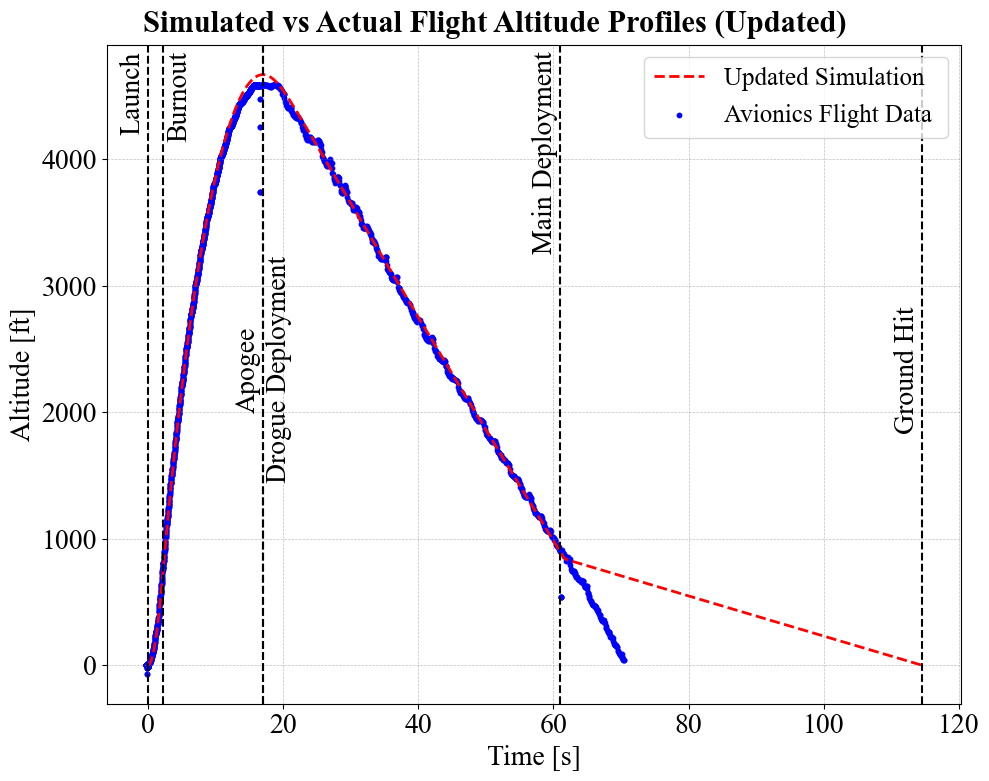

In [105]:
fig, ax = openrocket_to_plot('OpenRocket Full Scale Flight New.csv', color='r', label='Updated Simulation', linestyle='--')

ax.scatter(data_avionics2['Time [s]'], data_avionics2['Altitude [ft]'], c='b', label='Avionics Flight Data ', s=10)
# ax.plot(data_payload2['Time [s]'], data_payload2['Altitude [ft]'], linestyle='-', color='g', label='Payload Flight Data ', linewidth=2)

fig.suptitle('Simulated vs Actual Flight Altitude Profiles (Updated)', y=0.97)

ax.legend(loc='upper right')

# fig.savefig('Simulated vs Actual Flight Altitude Profiles Updated.png', dpi=300)

plt.show()

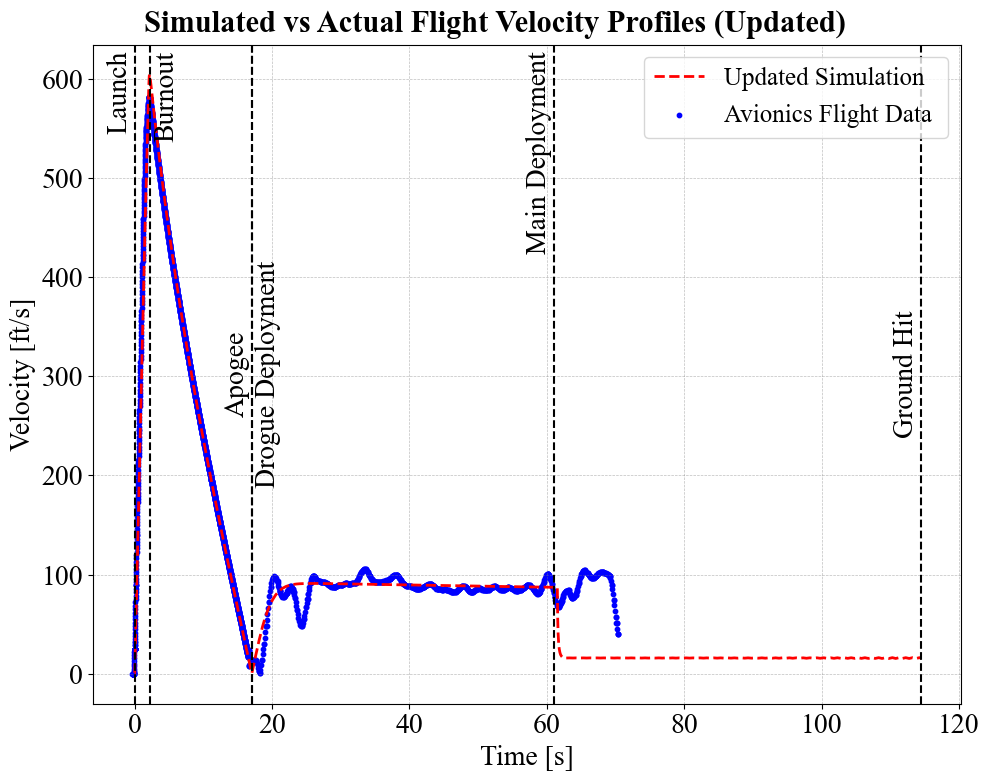

In [106]:
fig, ax = openrocket_to_plot('OpenRocket Full Scale Flight New.csv', color='r', label='Updated Simulation', linestyle='--', plot_type='velocity')

ax.scatter(data_avionics2['Time [s]'], np.abs(data_avionics2['Velocity [ft/s]']), c='b', label='Avionics Flight Data ', s=10)
# ax.plot(data_payload2['Time [s]'], data_payload2['Altitude [ft]'], linestyle='-', color='g', label='Payload Flight Data ', linewidth=2)

fig.suptitle('Simulated vs Actual Flight Velocity Profiles (Updated)', y=0.97)

ax.legend(loc='upper right')

# fig.savefig('Simulated vs Actual Flight Velocity Profiles Updated.png', dpi=300)

plt.show()

In [109]:
data_openrocket_new = pd.read_csv('OpenRocket Full Scale Flight New.csv', comment='#')
data_openrocket_new2 = data_openrocket_new.assign(**{'Altitude [ft]': data_openrocket_new['Altitude (ft)'], 'Time [s]': data_openrocket_new['Time (s)'], 'Velocity [ft/s]': data_openrocket_new['Total velocity (ft/s)'], 'Acceleration [ft/s²]': data_openrocket_new['Total acceleration (ft/s²)']})

# Comparing datasets by interpolating the altitudes
sim_common_times_new = np.linspace(0, data_openrocket_new['Time (s)'].max(), num=1000)

interp_sim_launch_new = interpolate.interp1d(data_openrocket_new['Time (s)'], data_openrocket_new['Altitude (ft)'], kind='linear', fill_value=0, bounds_error=False)

interp_altitudes_launch_new = interp_sim_launch_new(sim_common_times_new)
interp_altitudes_avionics_new = interp_avionics(sim_common_times_new)

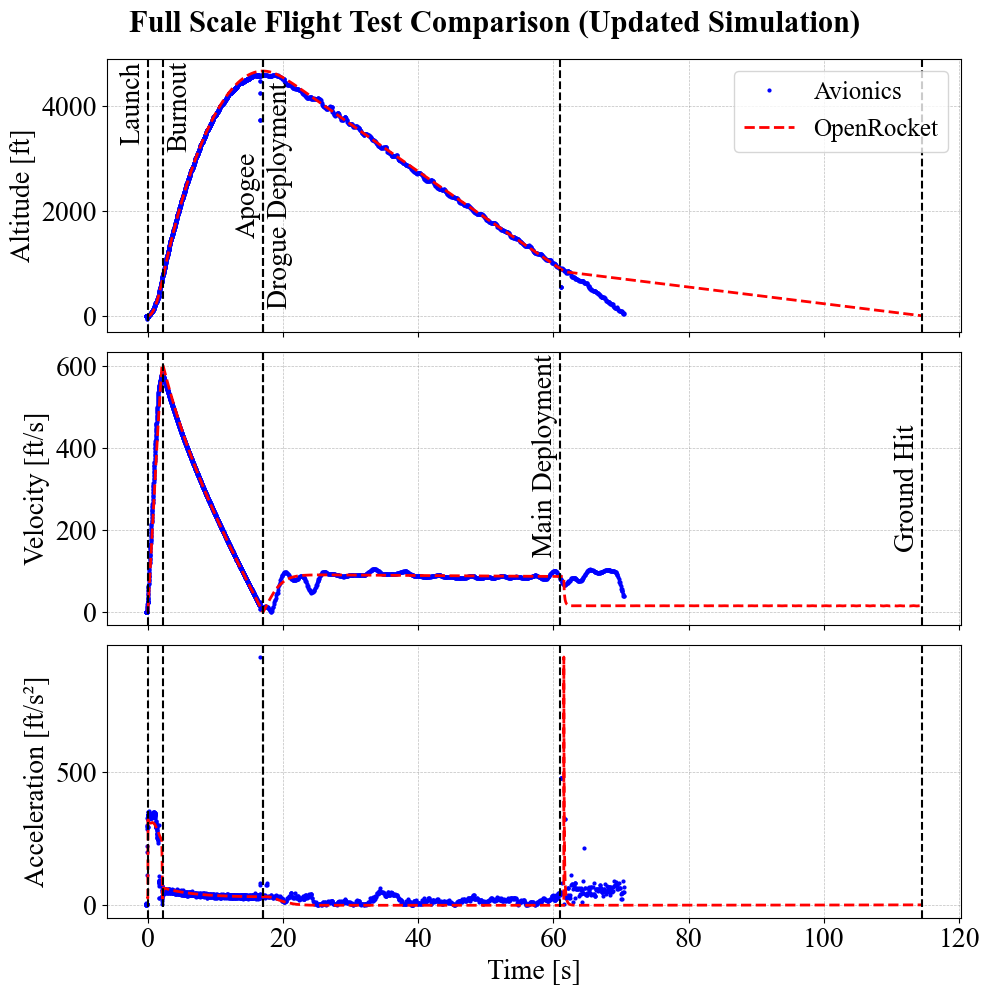

In [118]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
fig.set_tight_layout(True)

# Altitude comparison
ax1.plot(data_avionics2['Time [s]'], data_avionics2['Altitude [ft]'], linestyle='None', marker='o', color='b', label='Avionics', markersize=2)
ax1.plot(data_openrocket_new2['Time [s]'], data_openrocket_new2['Altitude [ft]'], linestyle='--', color='r', label='OpenRocket', linewidth=2)
ax1.set_ylabel('Altitude [ft]')
ax1.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Velocity comparison
ax2.plot(data_avionics2['Time [s]'], data_avionics2['Velocity [ft/s]'], linestyle='None', marker='o', color='b', markersize=2)
ax2.plot(data_openrocket_new2['Time [s]'], data_openrocket_new2['Velocity [ft/s]'], linestyle='--', color='r', linewidth=2)
ax2.set_ylabel('Velocity [ft/s]')
ax2.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Acceleration comparison
ax3.plot(data_avionics2['Time [s]'], np.abs(data_avionics2['Acceleration [ft/s²]']), linestyle='None', marker='o', color='b', markersize=2)
ax3.plot(data_openrocket_new2['Time [s]'], data_openrocket_new2['Acceleration [ft/s²]'], linestyle='--', color='r', linewidth=2)
ax3.set_ylabel('Acceleration [ft/s²]')
ax3.set_xlabel('Time [s]')
ax3.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Single legend for all three subplots (from first subplot's labels)
ax1.legend(loc='upper right')

# Adding vertical lines for important flight events, from OpenRocket file
with open('OpenRocket Full Scale Flight New.csv', 'r') as f:
    lines = f.readlines()
    event_lines = [line for line in lines if line.startswith('#') and 'Event' in line]

events = [line.split('Event ')[1].split(' occurred at t=')[0] for line in event_lines]
event_times = [float(line.split('t=')[1].split(' seconds')[0]) for line in event_lines]

plot_events = ['LAUNCH', 'BURNOUT', 'APOGEE', 'RECOVERY_DEVICE_DEPLOYMENT', 'GROUND_HIT']

drogue_deployed = False
for event, event_time in zip(events, event_times):
    if event in plot_events:
        for ax in [ax1, ax2, ax3]:
            ax.axvline(event_time, linestyle='--', color='k')

        if event == 'RECOVERY_DEVICE_DEPLOYMENT':
            if not drogue_deployed:
                event_label = 'Drogue Deployment'
                drogue_deployed = True
                ax1.text(event_time + 0.5, np.mean(ax1.get_ylim()), event_label, rotation=90, verticalalignment='center', horizontalalignment='left', fontsize=20)
            else:
                event_label = 'Main Deployment'
                ax2.text(event_time - 0.3, 0.99 * ax2.get_ylim()[1], event_label, rotation=90, verticalalignment='top', horizontalalignment='right', fontsize=20)
        elif event == 'BURNOUT':
            ax1.text(event_time + 0.5, 0.99 * ax1.get_ylim()[1], event.replace('_', ' ').title(), rotation=90, verticalalignment='top', horizontalalignment='left', fontsize=20)
        elif event == 'APOGEE':
            ax1.text(event_time - 0.3, np.mean(ax1.get_ylim()), event.replace('_', ' ').title(), rotation=90, verticalalignment='center', horizontalalignment='right', fontsize=20)
        elif event == 'GROUND_HIT':
            ax2.text(event_time - 0.3, np.mean(ax2.get_ylim()), event.replace('_', ' ').title(), rotation=90, verticalalignment='center', horizontalalignment='right', fontsize=20)
        else:
            ax1.text(event_time - 0.3, 0.99 * ax1.get_ylim()[1], event.replace('_', ' ').title(), rotation=90, verticalalignment='top', horizontalalignment='right', fontsize=20)

fig.suptitle('Full Scale Flight Test Comparison (Updated Simulation)', y=0.99)

fig.savefig('Full Scale Flight Test Comparison (Updated Simulation).png', dpi=300)
plt.show()

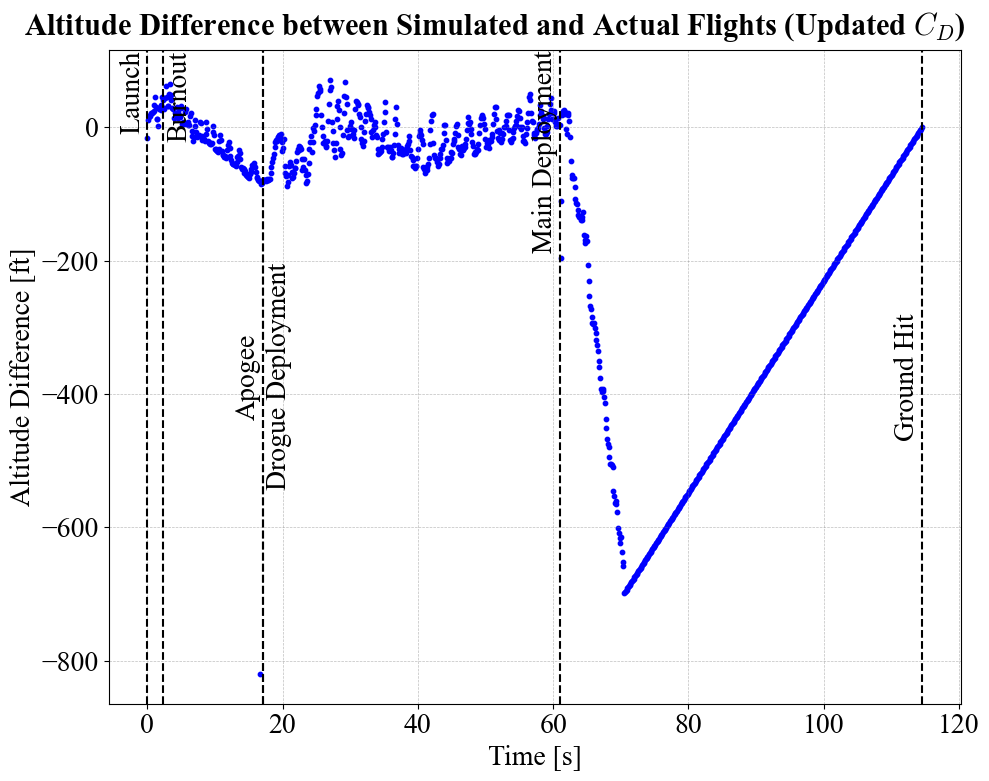

In [42]:
fig, ax = openrocket_to_plot('OpenRocket Full Scale Flight New.csv', code_to_run="ax.scatter(sim_common_times_new, interp_altitudes_avionics_new - interp_altitudes_launch_new, c='b', s=10)")

# ax.plot(common_times, interp_altitudes_avionics - interp_altitudes_launch, linestyle='-', color='r', label='Before $C_D$ Update', linewidth=2)

fig.suptitle('Altitude Difference between Simulated and Actual Flights (Updated $C_D$)', y=0.97)
# fig.set_tight_layout(True)

# ax.set_xlim(-2, 32)

ax.set_xlabel('Time [s]')
ax.set_ylabel('Altitude Difference [ft]')

# ax.legend(loc='upper right')

ax.grid(True)

# fig.savefig('Subscale_Altitude_Difference_Simulated_vs_Actual.png', dpi=300)

plt.show()

NameError: name 'interp_vel_avionics' is not defined

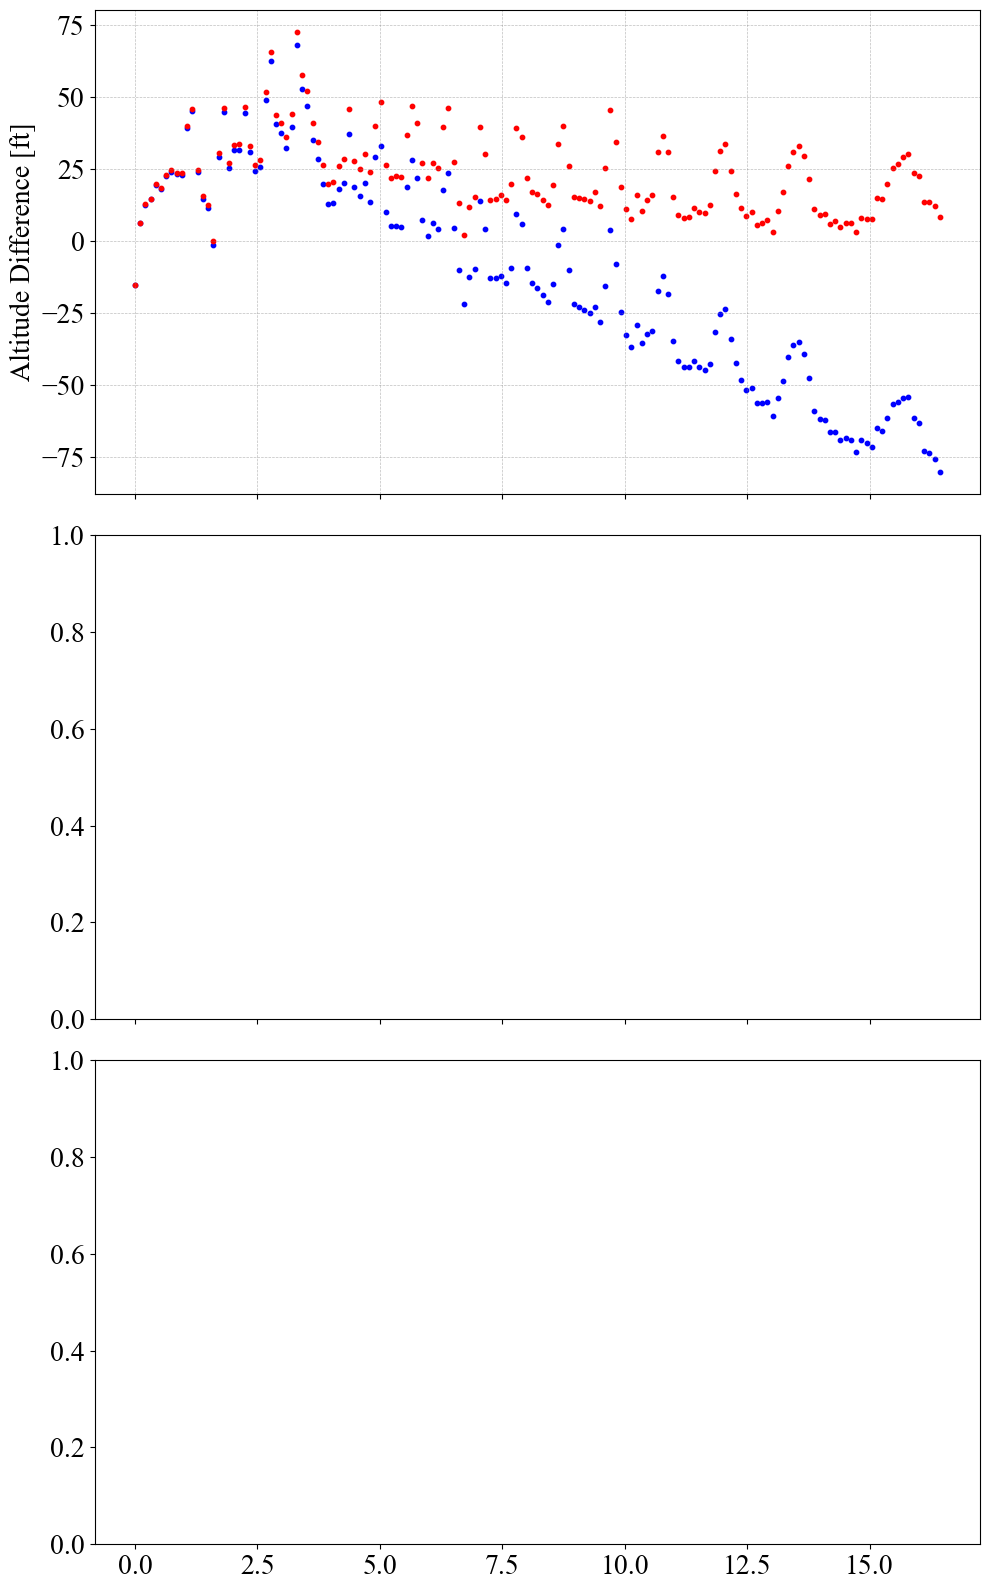

In [69]:
t_mask = common_times <= 16.5
t_cut = common_times[t_mask]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 16), sharex=True)
fig.set_tight_layout(True)

# Altitude difference
ax1.scatter(t_cut, (interp_altitudes_avionics - interp_altitudes_openrocket)[t_mask], c='b', s=10, label='OpenRocket Error')
ax1.scatter(t_cut, (interp_altitudes_avionics - interp_altitudes_custom)[t_mask], c='r', s=10, label='Custom Simulation Error')
ax1.set_ylabel('Altitude Difference [ft]')
ax1.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Velocity difference
ax2.scatter(t_cut, (interp_vel_avionics - interp_vel_openrocket)[t_mask], c='b', s=10, label='OpenRocket Error')
ax2.scatter(t_cut, (interp_vel_avionics - interp_vel_custom)[t_mask], c='r', s=10, label='Custom Simulation Error')
ax2.set_ylabel('Velocity Difference [ft/s]')
ax2.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Acceleration difference
ax3.scatter(t_cut, (interp_acc_avionics - interp_acc_openrocket)[t_mask], c='b', s=10, label='OpenRocket Error')
ax3.scatter(t_cut, (interp_acc_avionics - interp_acc_custom)[t_mask], c='r', s=10, label='Custom Simulation Error')
ax3.set_ylabel('Acceleration Difference [ft/s²]')
ax3.set_xlabel('Time [s]')
ax3.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

ax1.legend(loc='upper right')

# Adding vertical lines for flight events (excluding main deployment and ground hit)
with open('OpenRocket Full Scale Flight.csv', 'r') as f:
    lines = f.readlines()
    event_lines = [line for line in lines if line.startswith('#') and 'Event' in line]

events = [line.split('Event ')[1].split(' occurred at t=')[0] for line in event_lines]
event_times = [float(line.split('t=')[1].split(' seconds')[0]) for line in event_lines]

plot_events = ['LAUNCH', 'BURNOUT', 'APOGEE', 'RECOVERY_DEVICE_DEPLOYMENT']

drogue_deployed = False
for event, event_time in zip(events, event_times):
    if event in plot_events and event_time <= 16.5:
        if event == 'RECOVERY_DEVICE_DEPLOYMENT':
            if not drogue_deployed:
                drogue_deployed = True
            else:
                continue

        for ax in [ax1, ax2, ax3]:
            ax.axvline(event_time, linestyle='--', color='k')

        if event == 'RECOVERY_DEVICE_DEPLOYMENT':
            ax1.text(event_time + 0.2, np.mean(ax1.get_ylim()), 'Drogue Deployment', rotation=90, verticalalignment='center', horizontalalignment='left', fontsize=14)
        elif event == 'BURNOUT':
            ax1.text(event_time + 0.2, 0.99 * ax1.get_ylim()[1], event.replace('_', ' ').title(), rotation=90, verticalalignment='top', horizontalalignment='left', fontsize=14)
        elif event == 'APOGEE':
            ax1.text(event_time - 0.2, np.mean(ax1.get_ylim()), event.replace('_', ' ').title(), rotation=90, verticalalignment='center', horizontalalignment='right', fontsize=14)
        else:
            ax1.text(event_time - 0.2, 0.99 * ax1.get_ylim()[1], event.replace('_', ' ').title(), rotation=90, verticalalignment='top', horizontalalignment='right', fontsize=14)

fig.suptitle('Simulation Error Comparison', y=0.98)

plt.show()

In [43]:
# Drogue parachute fit
drogue_descent_velocities_openrocket_new = data_openrocket_new['Total velocity (ft/s)'][(data_openrocket_new['Time (s)'] > 15) & (data_openrocket_new['Time (s)'] < 25)]
print(f'Drogue Descent Rate under Launch Conditions: {np.mean(drogue_descent_velocities_openrocket_new):.2f} ft/s')

# Main parachute fit
main_descent_velocities_openrocket_new = data_openrocket_new['Total velocity (ft/s)'][(data_openrocket_new['Time (s)'] > 30) & (data_openrocket_new['Time (s)'] < 45)]
print(f'Main Descent Rate under Launch Conditions: {np.mean(main_descent_velocities_openrocket_new):.2f} ft/s')

Drogue Descent Rate under Launch Conditions: 42.09 ft/s
Main Descent Rate under Launch Conditions: 89.85 ft/s


## Determining coefficient of drag from coast phase

In [ ]:
# Coast phase is from motor burnout to apogee
motor_burnout = 2.4 + 0.2 # s
coast_phase_end = time_to_apogee_avionics - 3 # s
coast_phase_avionics = data_avionics2[(data_avionics2['Time [s]'] >= motor_burnout) & (data_avionics2['Time [s]'] <= coast_phase_end)].reset_index(drop=True)
coast_phase_openrocket = data_openrocket_new2[(data_openrocket_new2['Time [s]'] >= motor_burnout) & (data_openrocket_new2['Time [s]'] <= coast_phase_end)].reset_index(drop=True)
coast_phase_custom = data_custom2[(data_custom2['Time [s]'] >= motor_burnout) & (data_custom2['Time [s]'] <= coast_phase_end)].reset_index(drop=True)

coast_phase_avionics['Time [s]'] = coast_phase_avionics['Time [s]'] - coast_phase_avionics['Time [s]'][0]
coast_phase_avionics['Velocity [m/s]'] = coast_phase_avionics['Velocity [ft/s]'] * 0.3048

coast_phase_openrocket['Time [s]'] = coast_phase_openrocket['Time [s]'] - coast_phase_openrocket['Time [s]'][0]
coast_phase_openrocket['Velocity [m/s]'] = coast_phase_openrocket['Velocity [ft/s]'] * 0.3048

coast_phase_custom['Time [s]'] = coast_phase_custom['Time [s]'] - coast_phase_custom['Time [s]'][0]
coast_phase_custom['Velocity [m/s]'] = coast_phase_custom['Velocity [ft/s]'] * 0.3048

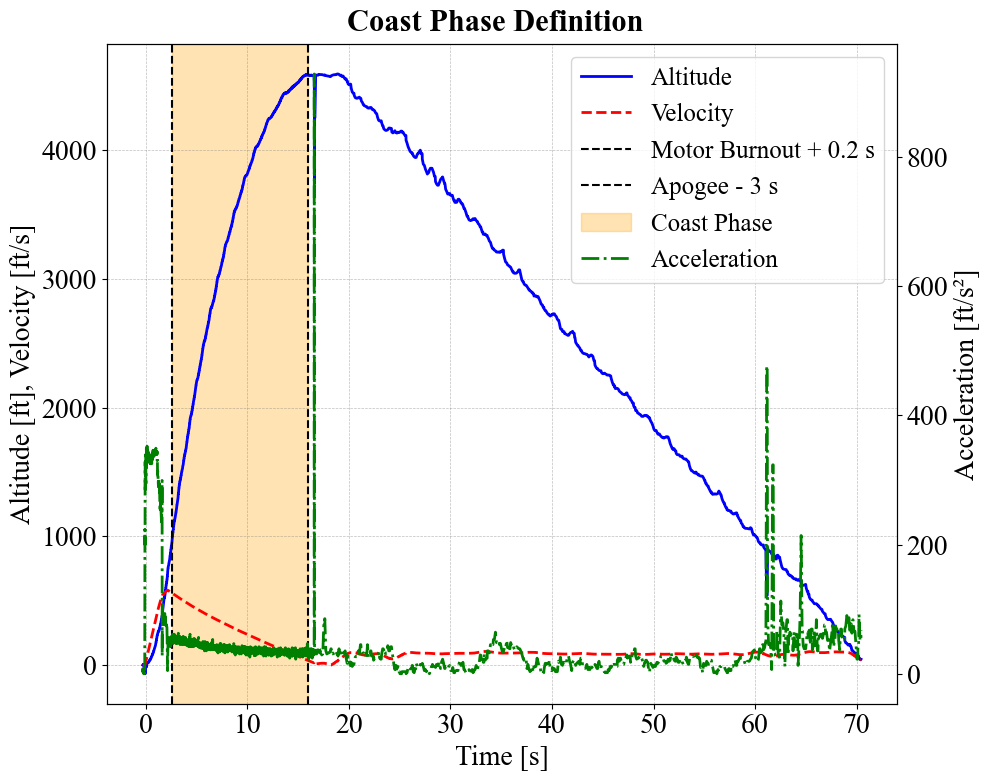

In [ ]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

ax.plot(data_avionics2['Time [s]'], data_avionics2['Altitude [ft]'], linestyle='-', color='b', label='Altitude', linewidth=2)
ax.plot(data_avionics2['Time [s]'], np.abs(data_avionics2['Velocity [ft/s]']), linestyle='--', color='r', label='Velocity', linewidth=2)

ax2 = ax.twinx()
ax2.plot(data_avionics2['Time [s]'], np.abs(data_avionics2['Acceleration [ft/s²]']), linestyle='-.', color='g', label='Acceleration', linewidth=2)

ax.axvline(motor_burnout, color='k', linestyle='--', label='Motor Burnout + 0.2 s')
ax.axvline(coast_phase_end, color='k', linestyle='--', label='Apogee - 3 s')

ax.axvspan(motor_burnout, coast_phase_end, color='orange', alpha=0.3, label='Coast Phase')

fig.suptitle('Coast Phase Definition', y=0.97)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Altitude [ft], Velocity [ft/s]')
ax2.set_ylabel('Acceleration [ft/s²]')

ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='upper right')

# fig.savefig('Coast Phase Definition.png', dpi=300)

plt.show()

In [96]:
def velocity_model(t, Cd, m, A, v0, rho_avg):
    # This is a simplified analytic solution for the coast phase velocity
    g = 9.81  # m/s²
    k = (0.5 * rho_avg * Cd * A) / m
    # Solution to dv/dt = -g - kv^2
    v_t = np.sqrt(g/k) * np.tan(np.arctan(v0 * np.sqrt(k/g)) - np.sqrt(g*k) * t)
    return v_t

# 1. Isolate your coast data (from burnout to apogee)
t_coast = coast_phase_avionics['Time [s]']
v_coast = coast_phase_avionics['Velocity [m/s]']

m_sub = 21.092 # kg
A_sub = np.pi * (0.16 / 2)**2 # m^2
v0_sub = v_coast.values[0] # m/s

pressures = coast_phase_avionics['pressure'] # Pa
temperature = 19.35 + 273.15 # K

rhos = pressures / (287.05 * temperature) # kg/m^3
rho = np.mean(rhos)

# 2. Fit for Cd
popt, pcov = optimize.curve_fit(lambda t, Cd: velocity_model(t, Cd, m_sub, A_sub, v0_sub, rho), 
                    t_coast, v_coast, p0=[0.5])

print(f"Calculated Full Scale Cd: {popt[0]}")
print(f'Calculated Full Scale Covariance: {pcov[0, 0]}')

Calculated Full Scale Cd: 0.4791113583992873
Calculated Full Scale Covariance: 3.0406242906597924e-08


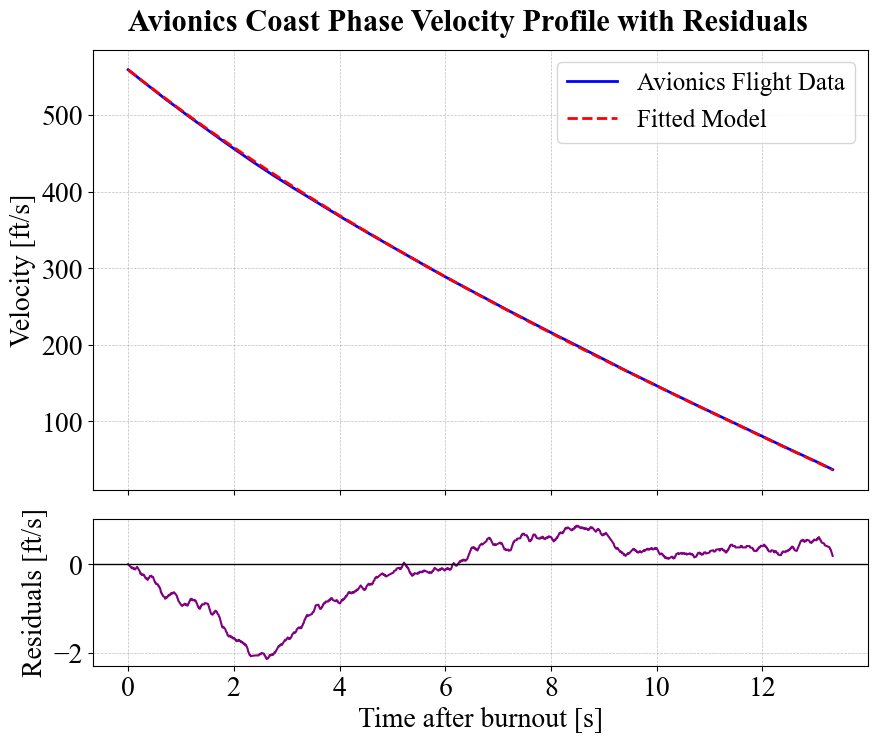

In [99]:
v_fitted = velocity_model(t_coast, popt[0], m_sub, A_sub, v0_sub, rho)

# 1. Calculate residuals
# Residual = Observed Data - Fitted Model
v_coast_ft = v_coast / 0.3048
v_fitted_avionics = v_fitted / 0.3048
residuals_avionics = v_coast_ft - v_fitted_avionics

# 2. Setup the figure and GridSpec (2 rows, 1 column)
fig = plt.figure(figsize=(10, 8))
# fig.set_tight_layout(True)
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.1)

fig.suptitle('Avionics Coast Phase Velocity Profile with Residuals', y=0.93)
# fig.set_tight_layout(True)

# Top Axis: Velocity Profile
ax0 = plt.subplot(gs[0])
ax0.plot(t_coast, v_coast_ft, linestyle='-', color='b', label='Avionics Flight Data', linewidth=2)
ax0.plot(t_coast, v_fitted_avionics, linestyle='--', color='r', label='Fitted Model', linewidth=2)

ax0.set_ylabel('Velocity [ft/s]')
ax0.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax0.legend(loc='upper right')

# Remove x-axis tick labels for the top plot to prevent overlap
plt.setp(ax0.get_xticklabels(), visible=False)

# Bottom Axis: Residuals
ax1 = plt.subplot(gs[1], sharex=ax0) # sharex ensures zoom/pan are synced
ax1.plot(t_coast, residuals_avionics, color='purple', linewidth=1.5)
ax1.axhline(0, color='black', linestyle='-', linewidth=1) # Zero-error line

ax1.set_xlabel('Time after burnout [s]')
ax1.set_ylabel('Residuals [ft/s]')
ax1.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

fig.savefig('Coast Phase Velocity Profile with Residuals.png', dpi=300)

# Adjust layout to prevent clipping
plt.show()

In [48]:
# 1. Isolate your coast data (from burnout to apogee)
t_coast = coast_phase_openrocket['Time [s]']
v_coast = coast_phase_openrocket['Velocity [m/s]']

m_sub = 21.092 # kg
A_sub = np.pi * (0.16 / 2)**2 # m^2
v0_sub = v_coast.values[0] # m/s

pressures = coast_phase_openrocket['Pressure [Pa]'] # Pa
temperature = 19.35 + 273.15 # K

rhos = pressures / (287.05 * temperature) # kg/m^3
rho = np.mean(rhos)

# 2. Fit for Cd
popt, pcov = optimize.curve_fit(lambda t, Cd: velocity_model(t, Cd, m_sub, A_sub, v0_sub, rho), 
                    t_coast, v_coast, p0=[0.5])

print(f"Calculated Full Scale Cd: {popt[0]}")
print(f'Calculated Full Scale Covariance: {pcov[0, 0]}')

Calculated Full Scale Cd: 0.5546997787050089
Calculated Full Scale Covariance: 2.594225975420479e-07


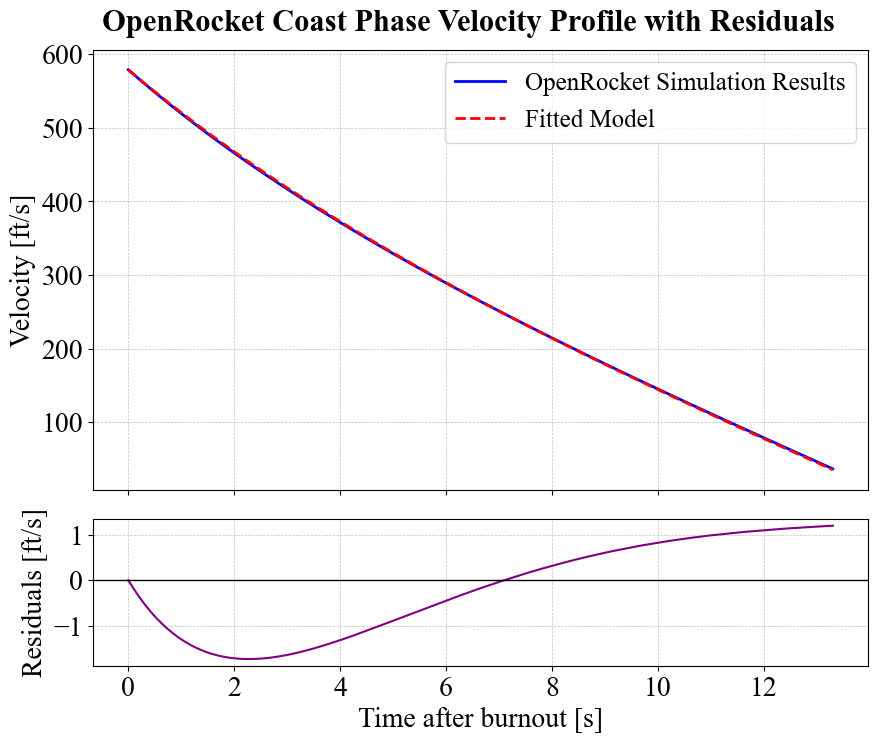

In [49]:
v_fitted = velocity_model(t_coast, popt[0], m_sub, A_sub, v0_sub, rho)

# 1. Calculate residuals
# Residual = Observed Data - Fitted Model
v_coast_ft = v_coast / 0.3048
v_fitted_openrocket = v_fitted / 0.3048
residuals_openrocket = v_coast_ft - v_fitted_openrocket

# 2. Setup the figure and GridSpec (2 rows, 1 column)
fig = plt.figure(figsize=(10, 8))
# fig.set_tight_layout(True)
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.1)

fig.suptitle('OpenRocket Coast Phase Velocity Profile with Residuals', y=0.93)

# Top Axis: Velocity Profile
ax0 = plt.subplot(gs[0])
ax0.plot(t_coast, v_coast_ft, linestyle='-', color='b', label='OpenRocket Simulation Results', linewidth=2)
ax0.plot(t_coast, v_fitted_openrocket, linestyle='--', color='r', label='Fitted Model', linewidth=2)

ax0.set_ylabel('Velocity [ft/s]')
ax0.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax0.legend(loc='upper right')

# Remove x-axis tick labels for the top plot to prevent overlap
plt.setp(ax0.get_xticklabels(), visible=False)

# Bottom Axis: Residuals
ax1 = plt.subplot(gs[1], sharex=ax0) # sharex ensures zoom/pan are synced
ax1.plot(t_coast, residuals_openrocket, color='purple', linewidth=1.5)
ax1.axhline(0, color='black', linestyle='-', linewidth=1) # Zero-error line

ax1.set_xlabel('Time after burnout [s]')
ax1.set_ylabel('Residuals [ft/s]')
ax1.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# fig.savefig('Coast Phase Velocity Profile with Residuals.png', dpi=300)

# Adjust layout to prevent clipping
plt.show()

In [50]:
# 1. Isolate your coast data (from burnout to apogee)
t_coast = coast_phase_custom['Time [s]']
v_coast = coast_phase_custom['Velocity [m/s]']

m_sub = 21.092 # kg
A_sub = np.pi * (0.16 / 2)**2 # m^2
v0_sub = v_coast.values[0] # m/s

pressures = coast_phase_custom['Pressure [Pa]'] # Pa
temperature = 19.35 + 273.15 # K

rhos = pressures / (287.05 * temperature) # kg/m^3
rho = np.mean(rhos)

# 2. Fit for Cd
popt, pcov = optimize.curve_fit(lambda t, Cd: velocity_model(t, Cd, m_sub, A_sub, v0_sub, rho), 
                    t_coast, v_coast, p0=[0.5])

print(f"Calculated Full Scale Cd: {popt[0]}")
print(f'Calculated Full Scale Covariance: {pcov[0, 0]}')

Calculated Full Scale Cd: 0.5748118577924038
Calculated Full Scale Covariance: 4.7712796257676984e-08


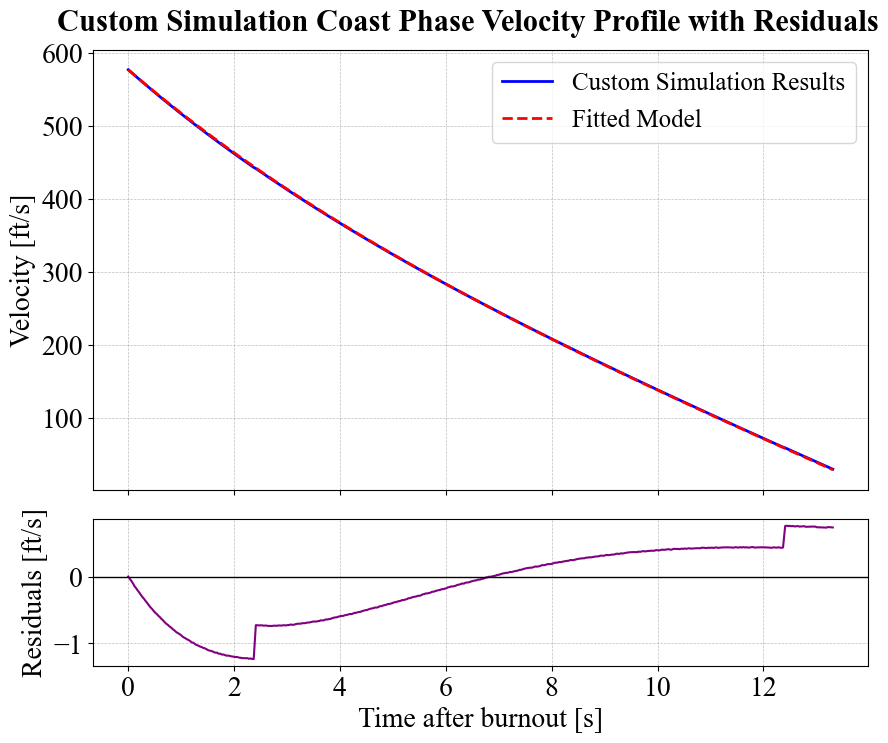

In [51]:
v_fitted = velocity_model(t_coast, popt[0], m_sub, A_sub, v0_sub, rho)

# 1. Calculate residuals
# Residual = Observed Data - Fitted Model
v_coast_ft = v_coast / 0.3048
v_fitted_custom = v_fitted / 0.3048
residuals_custom = v_coast_ft - v_fitted_custom

# 2. Setup the figure and GridSpec (2 rows, 1 column)
fig = plt.figure(figsize=(10, 8))
# fig.set_tight_layout(True)
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.1)

fig.suptitle('Custom Simulation Coast Phase Velocity Profile with Residuals', y=0.93)

# Top Axis: Velocity Profile
ax0 = plt.subplot(gs[0])
ax0.plot(t_coast, v_coast_ft, linestyle='-', color='b', label='Custom Simulation Results', linewidth=2)
ax0.plot(t_coast, v_fitted_custom, linestyle='--', color='r', label='Fitted Model', linewidth=2)

ax0.set_ylabel('Velocity [ft/s]')
ax0.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax0.legend(loc='upper right')

# Remove x-axis tick labels for the top plot to prevent overlap
plt.setp(ax0.get_xticklabels(), visible=False)

# Bottom Axis: Residuals
ax1 = plt.subplot(gs[1], sharex=ax0) # sharex ensures zoom/pan are synced
ax1.plot(t_coast, residuals_custom, color='purple', linewidth=1.5)
ax1.axhline(0, color='black', linestyle='-', linewidth=1) # Zero-error line

ax1.set_xlabel('Time after burnout [s]')
ax1.set_ylabel('Residuals [ft/s]')
ax1.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# fig.savefig('Coast Phase Velocity Profile with Residuals.png', dpi=300)

# Adjust layout to prevent clipping
plt.show()

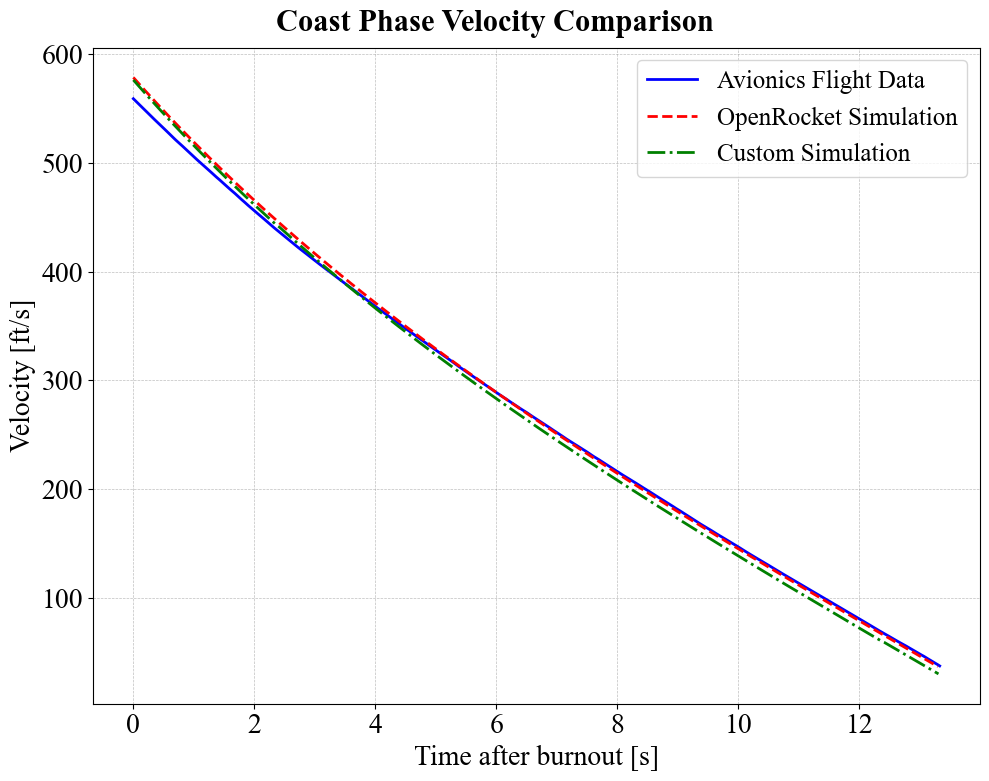

In [52]:
# Plotting all three velocities in one plot
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

fig.suptitle('Coast Phase Velocity Comparison', y=0.97)

ax.plot(coast_phase_avionics['Time [s]'], coast_phase_avionics['Velocity [m/s]'] / 0.3048, linestyle='-', color='b', label='Avionics Flight Data', linewidth=2)
ax.plot(coast_phase_openrocket['Time [s]'], coast_phase_openrocket['Velocity [m/s]'] / 0.3048, linestyle='--', color='r', label='OpenRocket Simulation', linewidth=2)
ax.plot(coast_phase_custom['Time [s]'], coast_phase_custom['Velocity [m/s]'] / 0.3048, linestyle='-.', color='g', label='Custom Simulation', linewidth=2)

ax.set_xlabel('Time after burnout [s]')
ax.set_ylabel('Velocity [ft/s]')
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax.legend(loc='upper right')

# fig.savefig('Coast Phase Velocity Comparison.png', dpi=300)
plt.show()

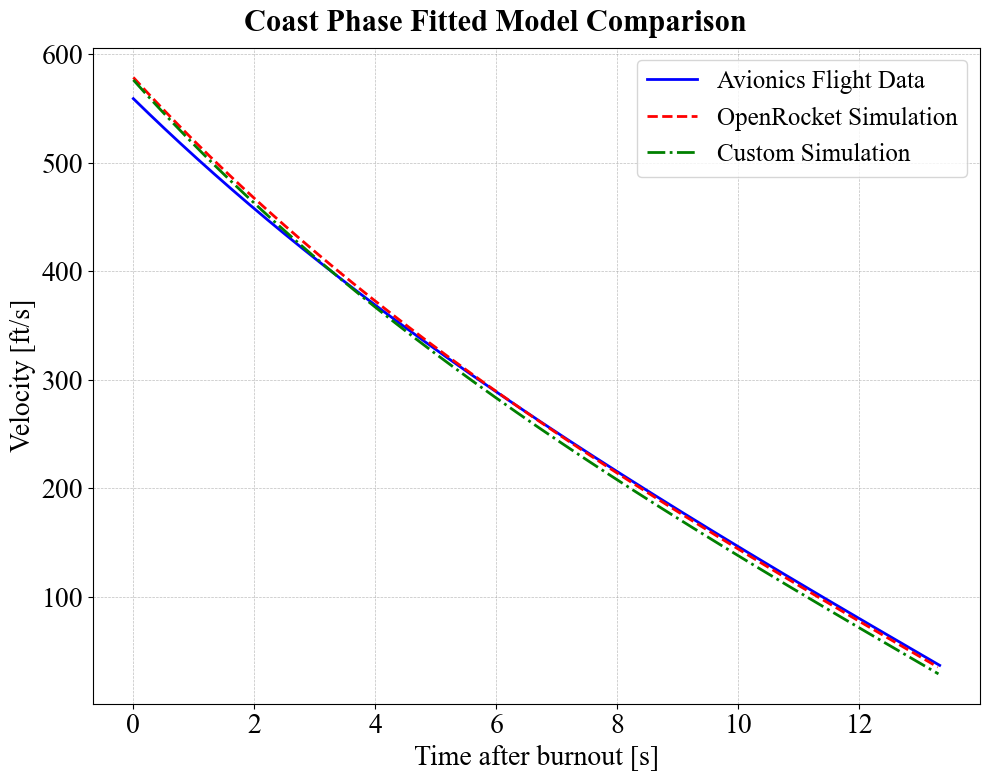

In [53]:
# Plotting all three velocities in one plot
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

fig.suptitle('Coast Phase Fitted Model Comparison', y=0.97)

ax.plot(coast_phase_avionics['Time [s]'], v_fitted_avionics, linestyle='-', color='b', label='Avionics Flight Data', linewidth=2)
ax.plot(coast_phase_openrocket['Time [s]'], v_fitted_openrocket, linestyle='--', color='r', label='OpenRocket Simulation', linewidth=2)
ax.plot(coast_phase_custom['Time [s]'], v_fitted_custom, linestyle='-.', color='g', label='Custom Simulation', linewidth=2)

ax.set_xlabel('Time after burnout [s]')
ax.set_ylabel('Velocity [ft/s]')
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax.legend(loc='upper right')

# fig.savefig('Coast Phase Velocity Comparison.png', dpi=300)
plt.show()

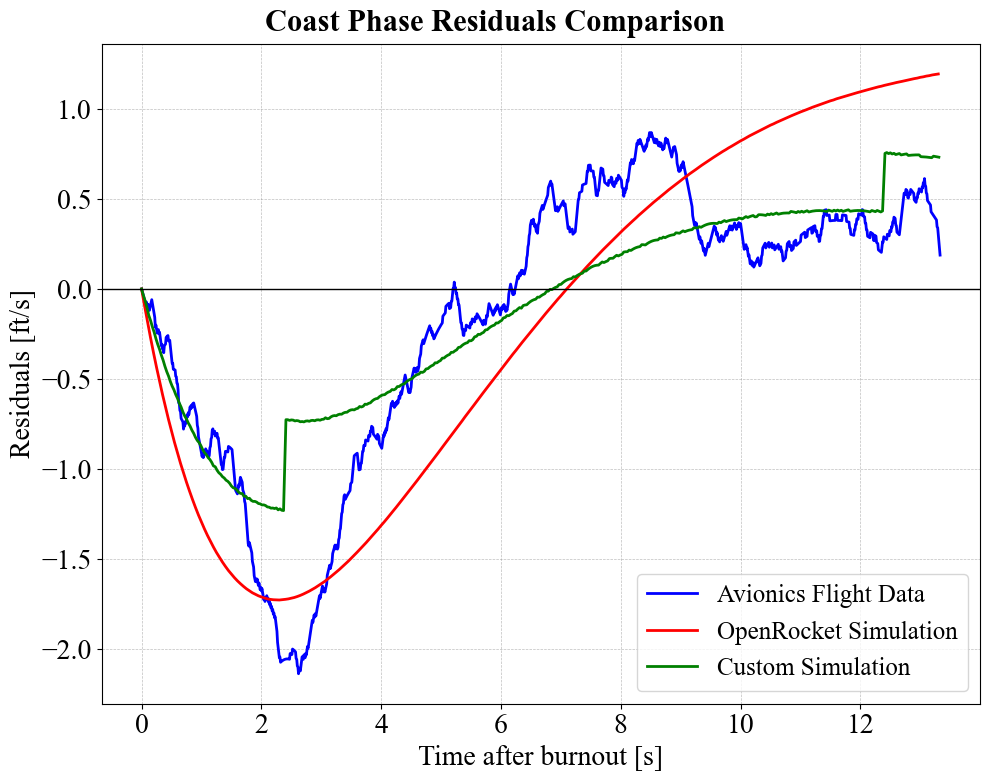

In [119]:
# Comparing residuals of all three fits
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

fig.suptitle('Coast Phase Residuals Comparison', y=0.97)

ax.plot(coast_phase_avionics['Time [s]'], residuals_avionics, color='blue', label='Avionics Flight Data', linewidth=2)
ax.plot(coast_phase_openrocket['Time [s]'], residuals_openrocket, color='red', label='OpenRocket Simulation', linewidth=2)
ax.plot(coast_phase_custom['Time [s]'], residuals_custom, color='green', label='Custom Simulation', linewidth=2)
ax.axhline(0, color='black', linestyle='-', linewidth=1) # Zero-error line

ax.set_xlabel('Time after burnout [s]')
ax.set_ylabel('Residuals [ft/s]')
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax.legend(loc='lower right')

fig.savefig('Coast Phase Residuals Comparison.png', dpi=300)
plt.show()